# 필요한 변수 크롤링 및 병합

In [43]:
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from urllib.request import Request, urlopen
import requests
from datetime import datetime
from functools import reduce

## USD KRW 크롤링

In [44]:
url = Request('https://kr.investing.com/currencies/usd-krw-historical-data', headers={'user-agent': 'Mozilla/5.0 (Windows NT 11.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.5414.76 Safari/537.36 NetHelper70'})

res = urlopen(url)
bs = BeautifulSoup(res, 'html.parser')

table = bs.select_one('#__next > div.desktop\:relative.desktop\:bg-background-default > div > div > div.grid.gap-4.tablet\:gap-6.grid-cols-4.tablet\:grid-cols-8.desktop\:grid-cols-12.grid-container--fixed-desktop.general-layout_main__lRLYJ > main > div > div:nth-child(4) > div > div:nth-child(1) > div > div.border.border-main > div > table')

rows=table.select('#__next > div.desktop\:relative.desktop\:bg-background-default > div > div > div.grid.gap-4.tablet\:gap-6.grid-cols-4.tablet\:grid-cols-8.desktop\:grid-cols-12.grid-container--fixed-desktop.general-layout_main__lRLYJ > main > div > div:nth-child(4) > div > div:nth-child(1) > div > div.border.border-main > div > table > tbody > tr')

a_list = []
b_list = []

for i in rows:
    a = i.find('time').text.replace(' ', '')
    a_list.append(a)
    
    b = i.find('td', attrs={'dir': 'ltr'}).text.replace(',', '')
    b_list.append(b)

data = {'date': a_list, 'price': b_list}
df1 = pd.DataFrame(data)
df1 = df1.sort_values(by='date')

## 달러지수

In [45]:
url = Request('https://kr.investing.com/currencies/us-dollar-index-historical-data', headers={'user-agent': 'Mozilla/5.0 (Windows NT 11.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.5414.76 Safari/537.36 NetHelper70'})

res = urlopen(url)
bs = BeautifulSoup(res, 'html.parser')

table = bs.find('table', {'id': 'curr_table'})

data = []
for row in table.find_all('tr'):
    cols = row.find_all('td')
    cols = [col.text.strip() for col in cols[:2]]  # Only extract first 2 columns
    data.append(cols)

columns = ['date', 'price']

df2 = pd.DataFrame(data[1:], columns=columns)

df2['date'] = pd.to_datetime(df2['date'], format='%Y년 %m월 %d일')
df2 = df2.sort_values(by='date')
df2['date'] = df2['date'].apply(lambda x: datetime.strftime(x, '%Y-%m-%d'))

##  crb

In [46]:
url = Request('https://kr.investing.com/indices/thomson-reuters---jefferies-crb-historical-data', headers={'user-agent': 'Mozilla/5.0 (Windows NT 11.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.5414.76 Safari/537.36 NetHelper70'})

res = urlopen(url)
bs = BeautifulSoup(res, 'html.parser')

table=bs.select_one('#__next > div.desktop\:relative.desktop\:bg-background-default > div > div > div.grid.gap-4.tablet\:gap-6.grid-cols-4.tablet\:grid-cols-8.desktop\:grid-cols-12.grid-container--fixed-desktop.general-layout_main__lRLYJ > main > div > div:nth-child(4) > div > div > div.border.border-main > div > table')
# print(table)

rows=table.select('#__next > div.desktop\:relative.desktop\:bg-background-default > div > div > div.grid.gap-4.tablet\:gap-6.grid-cols-4.tablet\:grid-cols-8.desktop\:grid-cols-12.grid-container--fixed-desktop.general-layout_main__lRLYJ > main > div > div > div > div > div.border.border-main > div > table > tbody > tr')

a_list = []
b_list = []

for i in rows:
    a = i.find('time').text.replace(' ', '')
    a_list.append(a)
    
    b = i.find('td', attrs={'dir': 'ltr'}).text
    b_list.append(b)

data = {'date': a_list, 'price': b_list}
df3 = pd.DataFrame(data)
df3 = df3.sort_values(by='date')
# print(df4)

## 병합

In [47]:
merged=reduce(lambda x,y: pd.merge(x,y, on='date', how ='outer'), [df1, df2, df3])

merged.columns=['date', 'USD/KRW', '달러지수', 'crb']

merged['date'] = pd.to_datetime(merged['date'])
merged['USD/KRW'] = pd.to_numeric(merged['USD/KRW'], errors='coerce')
merged['달러지수'] = pd.to_numeric(merged['달러지수'], errors='coerce')
merged['crb'] = pd.to_numeric(merged['crb'], errors='coerce')

existing_data=pd.read_excel('./최종지수 (1).xlsx')

combined_data = pd.concat([existing_data, merged])

combined_data = combined_data.drop_duplicates(subset=['date'],keep='first').sort_values('date')
# print(combined_data)

combined_data.to_excel('./최종지수 (1).xlsx', index=False)

In [48]:
combined_data

,date,USD/KRW,달러지수,crb
0,1998-01-02,1695.00,100.040,179.23
1,1998-01-03,NaN,NaN,NaN
2,1998-01-04,NaN,NaN,NaN
3,1998-01-05,1780.00,101.010,177.22
4,1998-01-06,1746.50,101.380,176.45
...,...,...,...,...
9212,2023-03-27,1302.31,102.715,NaN
9213,2023-03-28,1297.33,102.065,263.49
9214,2023-03-29,1297.19,102.155,NaN
9215,2023-03-30,NaN,102.360,NaN


# 모델

## 자료불러오기

In [49]:
최종지수 = pd.read_excel('./최종지수 (1).xlsx').set_index('date').fillna(method='ffill')

In [50]:
최종지수 = 최종지수['1998-03-23':]

In [51]:
최종지수.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9137 entries, 1998-03-23 to 2023-03-31
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   USD/KRW  9137 non-null   float64
 1   달러지수     9137 non-null   float64
 2   crb      9137 non-null   float64
dtypes: float64(3)
memory usage: 285.5 KB


In [52]:
최종지수

,USD/KRW,달러지수,crb
date,,,
1998-03-23,1367.00,100.150,172.75
1998-03-24,1376.50,100.220,170.01
1998-03-25,1388.00,99.950,171.38
1998-03-26,1394.50,99.540,172.66
1998-03-27,1378.75,100.140,172.47
...,...,...,...
2023-03-27,1302.31,102.715,258.49
2023-03-28,1297.33,102.065,263.49
2023-03-29,1297.19,102.155,263.49


## 결측치 및 자료 길이 확인

In [53]:
np.sum(최종지수.isna())

USD/KRW    0
달러지수       0
crb        0
dtype: int64

In [54]:
len(최종지수)

9137

In [55]:
data = 최종지수

## 파라미터 조정

In [56]:
import tensorflow as tf
import matplotlib as mpl
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

In [57]:
BATCH_SIZE = 32
TRAIN_SPLIT = int(len(data)*0.9)
EVALUATION_INTERVAL = int(TRAIN_SPLIT/BATCH_SIZE)
EPOCHS = 100
tf.random.set_seed(13)
VALIDATION_EVALU_INTERVAL = int((len(data)-TRAIN_SPLIT)/BATCH_SIZE)
BUFFER_SIZE = 64
past_history = 10
future_target = 1
STEP = 1
drop_rate = 0.1
patience =40

In [58]:
TRAIN_SPLIT

8223

## 데이터 표준화 

In [59]:
dataset = data.values
data_mean = dataset.mean(axis=0)
data_std = dataset.std(axis=0)
dataset = (dataset-data_mean)/data_std

print(dataset.shape)
print(dataset)

(9137, 3)
[[ 2.0654676   0.71878697 -0.95847168]
 [ 2.15412062  0.72511729 -0.99801426]
 [ 2.26143743  0.70070035 -0.97824297]
 ...
 [ 1.41400791  0.90010529  0.35105141]
 [ 1.41400791  0.91864407  0.35105141]
 [ 1.48539692  0.88834899  0.35105141]]


## 학습과 검증데이터 분리

In [60]:
def split_data(dataset, target, start_index, end_index, history_size, target_size, step):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size+1
    

    for i in range(start_index, end_index):
        labels.append(target[i:i + target_size])
        indices = range(i - history_size, i, step)
        data.append(dataset[indices])
    
    return np.array(data), np.array(labels)

In [61]:

x_train, y_train = split_data(dataset, dataset[:,0], 0, TRAIN_SPLIT, past_history, future_target, STEP)

x_val, y_val = split_data(dataset, dataset[:,0], TRAIN_SPLIT, None, past_history, future_target, STEP)
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
train_data= tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_data = val_data.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

(8213, 10, 3)
(8213, 1)
(904, 10, 3)
(904, 1)


In [102]:
pd.DataFrame(dataset[TRAIN_SPLIT:,:])

,0,1,2
0,0.267398,0.221134,-1.310458
1,0.267398,0.221134,-1.310458
2,0.197689,0.186950,-1.305119
3,0.215232,0.153128,-1.333549
4,0.177158,0.153309,-1.308294
...,...,...,...
909,1.461787,0.950748,0.278893
910,1.415314,0.891966,0.351051
911,1.414008,0.900105,0.351051
912,1.414008,0.918644,0.351051


## 모델 구축 & 학습

In [93]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.LSTM(200, input_shape = x_train.shape[-2:], activation='tanh'))
model.add(tf.keras.layers.Dense(future_target))


model.compile(optimizer=tf.keras.optimizers.RMSprop(), loss='mae')
earlystopping = EarlyStopping(monitor='val_loss',patience=patience, mode='auto')
checkpoint = ModelCheckpoint( 'model_weight.ckpt',
                             save_best_only=True,
                              save_weights_only=True,
                              monitor='val_loss', 
                              verbose=1)
model.fit(train_data, epochs=EPOCHS, steps_per_epoch=EVALUATION_INTERVAL,
          validation_data=val_data, validation_steps= VALIDATION_EVALU_INTERVAL,
          callbacks=[earlystopping,checkpoint], verbose=1)


Epoch 1/100
251/256 [============================>.] - ETA: 0s - loss: 0.1394
Epoch 1: val_loss improved from inf to 0.16179, saving model to model_weight.ckpt
256/256 [==============================] - 5s 11ms/step - loss: 0.1385 - val_loss: 0.1618
Epoch 2/100
253/256 [============================>.] - ETA: 0s - loss: 0.0851
Epoch 2: val_loss improved from 0.16179 to 0.08554, saving model to model_weight.ckpt
256/256 [==============================] - 2s 8ms/step - loss: 0.0849 - val_loss: 0.0855
Epoch 3/100
254/256 [============================>.] - ETA: 0s - loss: 0.0661
Epoch 3: val_loss improved from 0.08554 to 0.06574, saving model to model_weight.ckpt
256/256 [==============================] - 2s 9ms/step - loss: 0.0662 - val_loss: 0.0657
Epoch 4/100
254/256 [============================>.] - ETA: 0s - loss: 0.0590
Epoch 4: val_loss improved from 0.06574 to 0.06276, saving model to model_weight.ckpt
256/256 [==============================] - 2s 9ms/step - loss: 0.0591 - val_loss

249/256 [============================>.] - ETA: 0s - loss: 0.0403
Epoch 37: val_loss did not improve from 0.03645
256/256 [==============================] - 2s 8ms/step - loss: 0.0402 - val_loss: 0.0407
Epoch 38/100
254/256 [============================>.] - ETA: 0s - loss: 0.0401
Epoch 38: val_loss did not improve from 0.03645
256/256 [==============================] - 2s 8ms/step - loss: 0.0400 - val_loss: 0.0368
Epoch 39/100
255/256 [============================>.] - ETA: 0s - loss: 0.0400
Epoch 39: val_loss did not improve from 0.03645
256/256 [==============================] - 2s 8ms/step - loss: 0.0400 - val_loss: 0.0449
Epoch 40/100
252/256 [============================>.] - ETA: 0s - loss: 0.0397
Epoch 40: val_loss did not improve from 0.03645
256/256 [==============================] - 2s 7ms/step - loss: 0.0397 - val_loss: 0.0433
Epoch 41/100
251/256 [============================>.] - ETA: 0s - loss: 0.0394
Epoch 41: val_loss improved from 0.03645 to 0.03596, saving model to m

Epoch 75/100
254/256 [============================>.] - ETA: 0s - loss: 0.0381
Epoch 75: val_loss did not improve from 0.03596
256/256 [==============================] - 2s 8ms/step - loss: 0.0380 - val_loss: 0.0360
Epoch 76/100
255/256 [============================>.] - ETA: 0s - loss: 0.0375
Epoch 76: val_loss did not improve from 0.03596
256/256 [==============================] - 2s 8ms/step - loss: 0.0374 - val_loss: 0.0366
Epoch 77/100
256/256 [==============================] - ETA: 0s - loss: 0.0376
Epoch 77: val_loss did not improve from 0.03596
256/256 [==============================] - 2s 7ms/step - loss: 0.0376 - val_loss: 0.0363
Epoch 78/100
254/256 [============================>.] - ETA: 0s - loss: 0.0375
Epoch 78: val_loss did not improve from 0.03596
256/256 [==============================] - 2s 8ms/step - loss: 0.0373 - val_loss: 0.0385
Epoch 79/100
247/256 [===========================>..] - ETA: 0s - loss: 0.0379
Epoch 79: val_loss did not improve from 0.03596
256/256 [

In [63]:
model.load_weights('model_weight.ckpt')

# Loss  시각화

In [64]:
# Loss 함수
def plot_train_history(model, title):
    loss = model.history.history['loss']
    val_loss = model.history.history['val_loss']

    epochs = range(len(loss))

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.legend()

    plt.show()

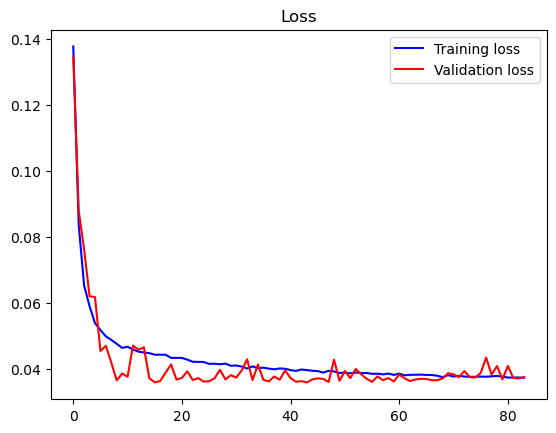

In [65]:
plot_train_history(model, 'Loss')

# 모델 결과 (MAE , R-square)

In [94]:
FX_Mean = data.values[:,0].mean()
FX_St = data.values[:,0].std()

## 예측치와 실제값

In [95]:
predict = model.predict(x_val)*FX_St+FX_Mean 
Y = y_val*FX_St+FX_Mean

29/29 [==============================] - 0s 4ms/step


In [104]:
pd.DataFrame(model.predict(x_val))

29/29 [==============================] - 0s 3ms/step


,0
0,0.101513
1,0.170598
2,0.103084
3,0.048696
4,-0.024675
...,...
899,1.397753
900,1.453701
901,1.405798
902,1.404799


In [108]:
display(pd.DataFrame(predict)), display(pd.DataFrame(Y))

,0
0,1156.543823
1,1163.947021
2,1156.712280
3,1150.884033
4,1143.021606
...,...
899,1295.448120
900,1301.443359
901,1296.310181
902,1296.203125


,0
0,1164.37
1,1157.26
2,1151.11
3,1143.52
4,1143.52
...,...
899,1302.31
900,1297.33
901,1297.19
902,1297.19


(None, None)

## 검증데이터의 MAE와 R2

In [68]:
from sklearn.metrics import mean_absolute_error ,r2_score
mae = mean_absolute_error(Y, predict)
r2 = r2_score(Y,predict)
print(f'mae: {mae:.5f}')
print(f'r2: {r2:.5f}')


mae: 3.88489
r2: 0.99575


## 가장 큰 오차, 가장 작은 오차 살피기

In [69]:
np.set_printoptions(suppress=True, precision = 5)
print(f'max: {np.max(np.abs(Y-predict)):.5f}원')
print(f'min: {np.min(np.abs(Y-predict)):.5f}원')

max: 34.88593원
min: 0.00037원


In [106]:
pd.DataFrame(Y-predict)

,0
0,7.826177
1,-6.687021
2,-5.602280
3,-7.364033
4,0.498394
...,...
899,6.861880
900,-4.113359
901,0.879819
902,0.986875


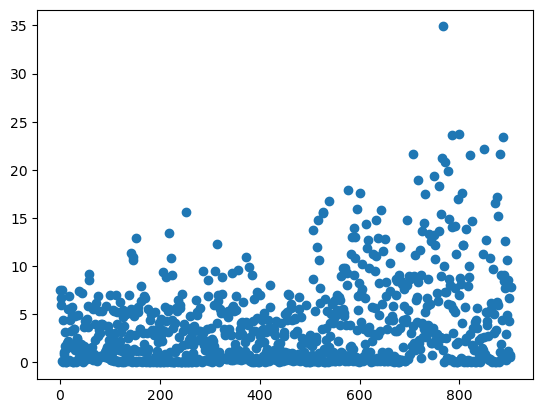

In [70]:
plt.plot(np.abs(Y-predict), 'o')
plt.show()

## 예측 시각화 - 그래프 그리기

In [71]:
def create_time_steps(length):
    return list(range(-length, 0))

def multi_step_plot(history, true_future, prediction):
    plt.figure(figsize=(12, 6))
    num_in = create_time_steps(len(history))
    num_out = len(true_future)
    
    # history[:, 1] : 3개의 독립변 수 중 2번째 컬럼이 기온 데이터
    plt.plot(num_in, np.array(history[:,0]), label='History')
    plt.plot(np.arange(num_out)/STEP, np.array(true_future), 'bo', label='True Exchange Rate')
    if prediction.any():
        plt.plot(np.arange(num_out)/STEP, np.array(prediction), 'ro', label='Predicted Future')
    plt.legend()
    plt.show()
    


1/1 [==============================] - 0s 379ms/step


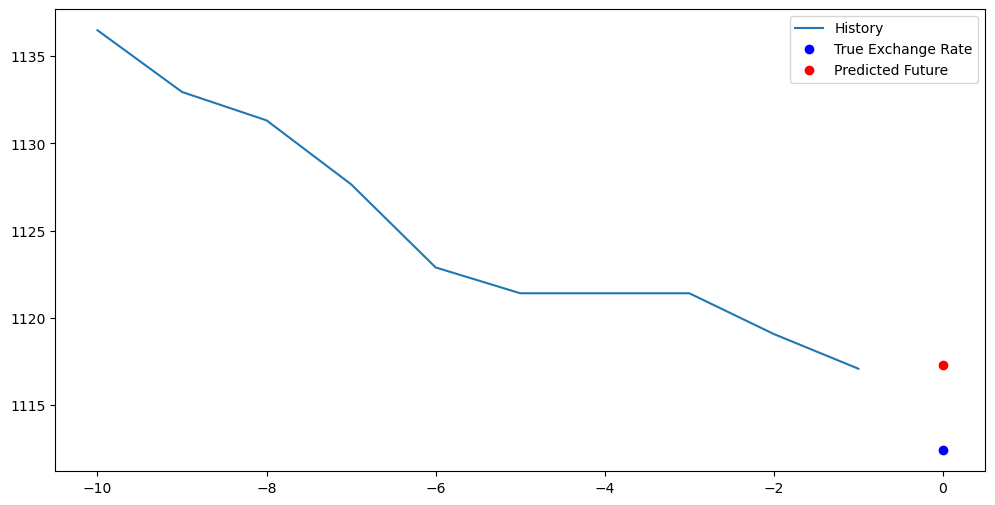

1/1 [==============================] - 0s 20ms/step


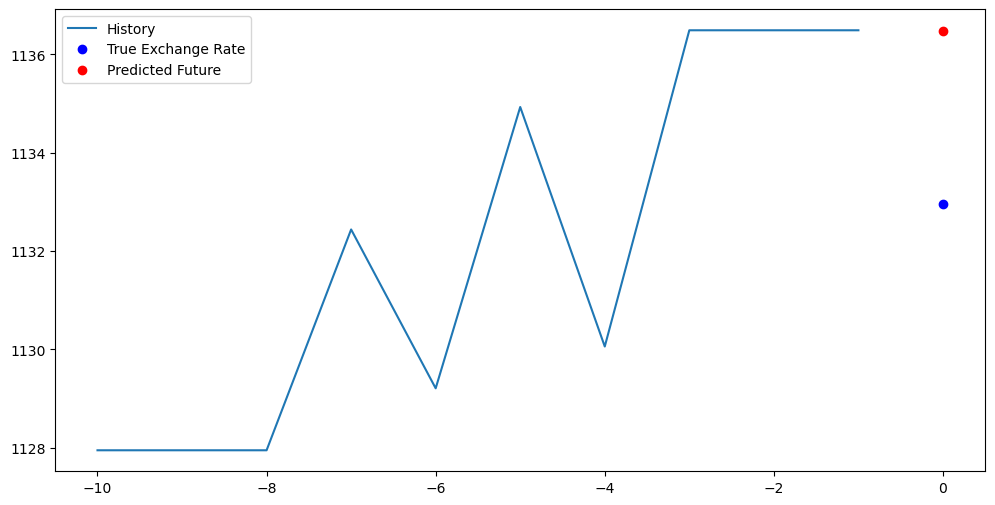

1/1 [==============================] - 0s 21ms/step


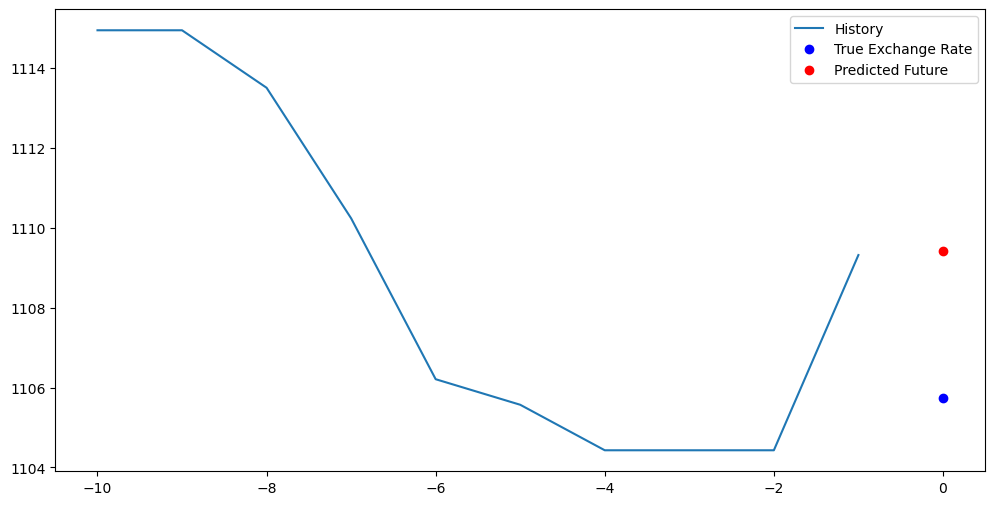

1/1 [==============================] - 0s 25ms/step


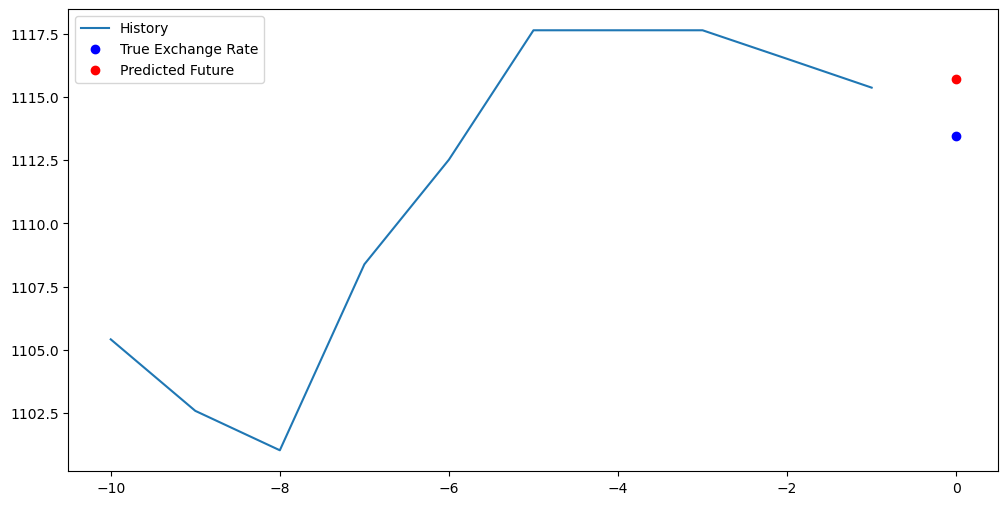

1/1 [==============================] - 0s 34ms/step


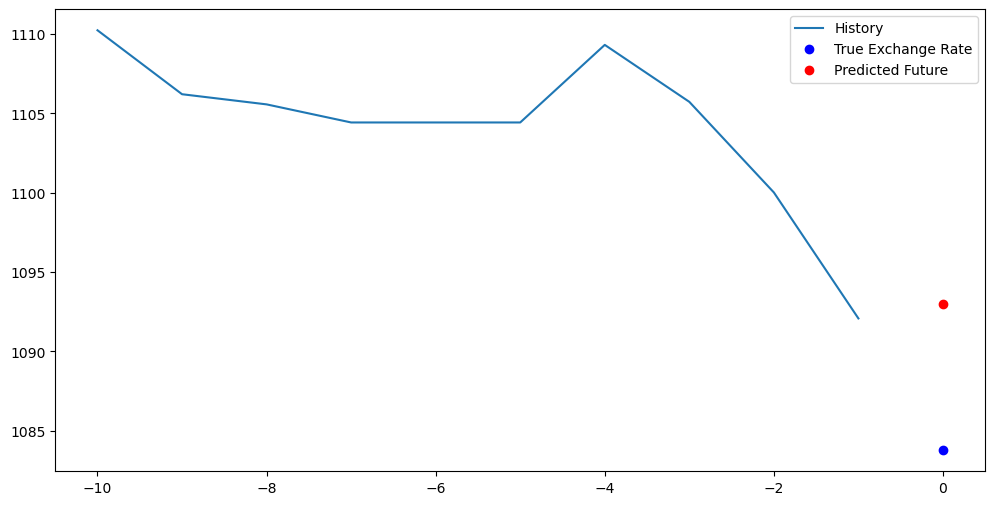

1/1 [==============================] - 0s 21ms/step


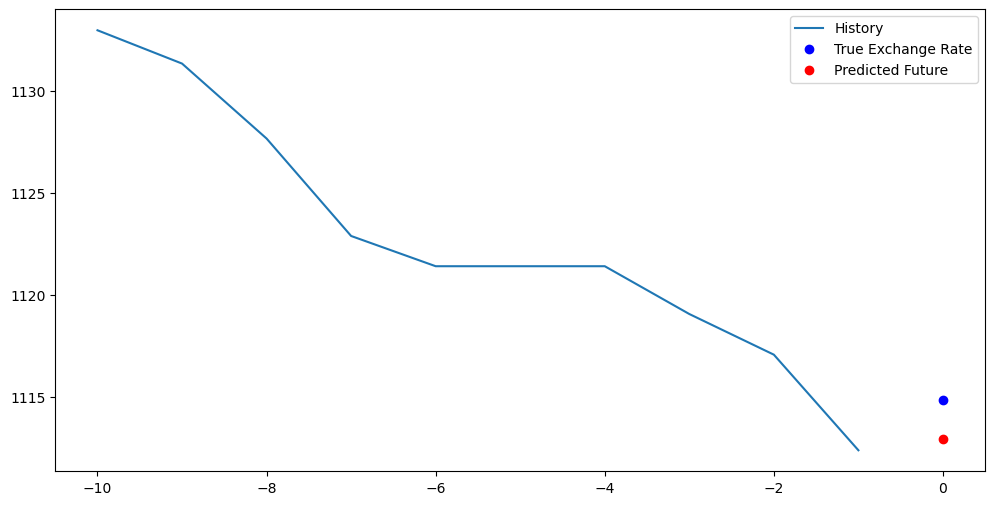

1/1 [==============================] - 0s 17ms/step


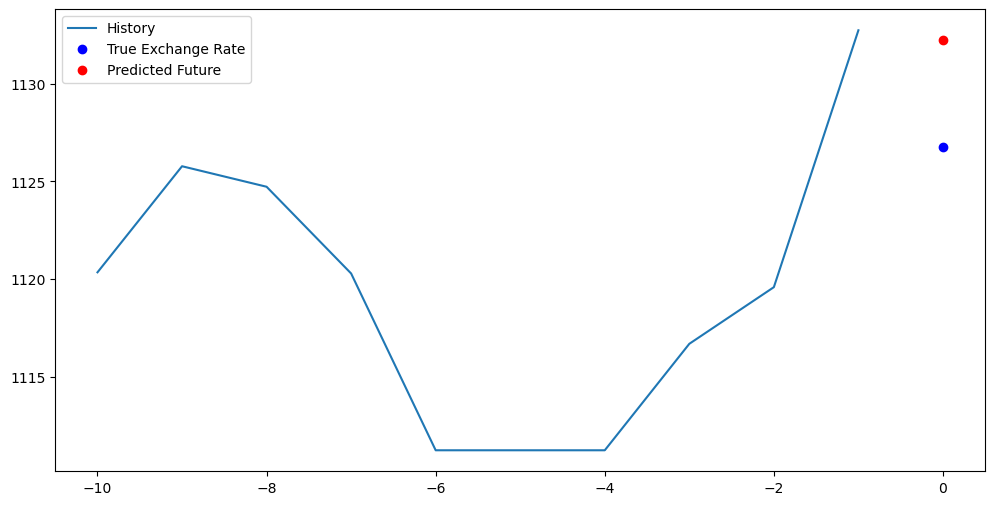

1/1 [==============================] - 0s 41ms/step


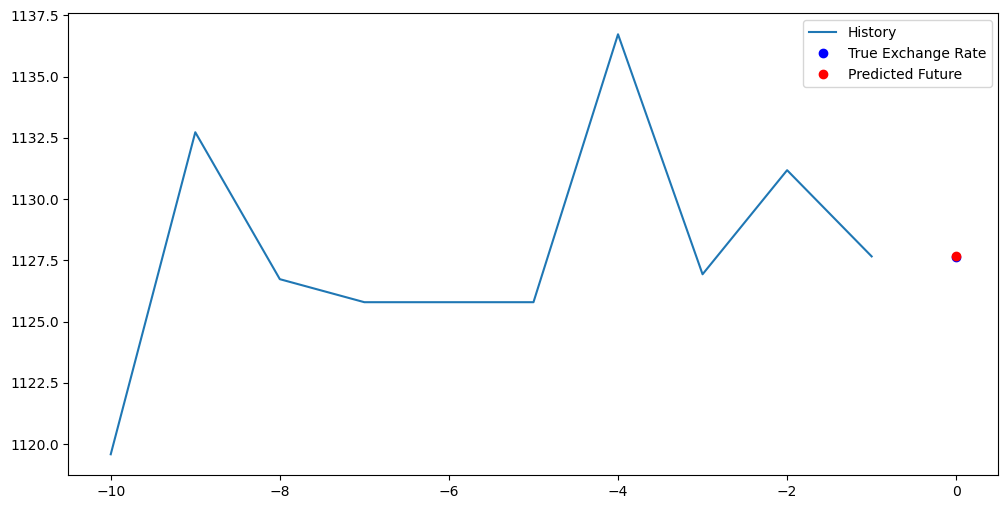

1/1 [==============================] - 0s 25ms/step


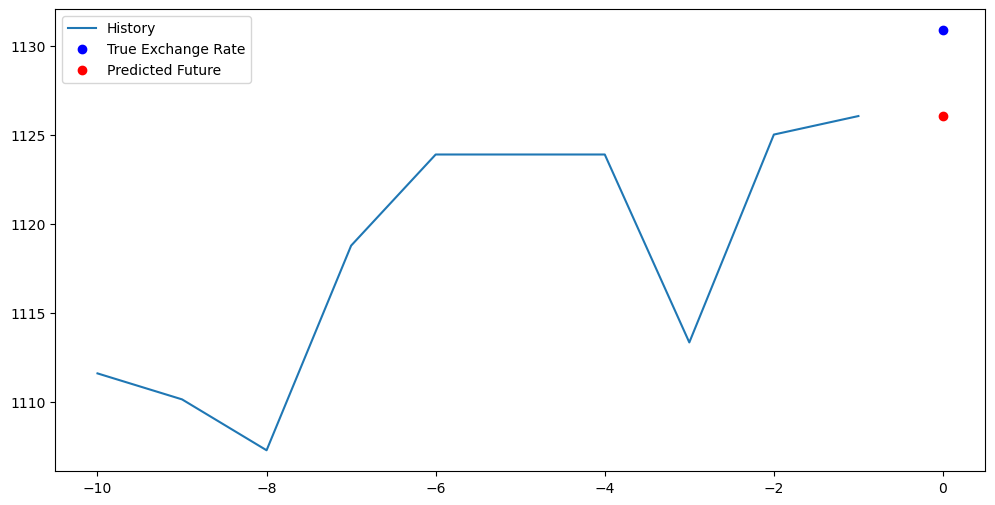

1/1 [==============================] - 0s 16ms/step


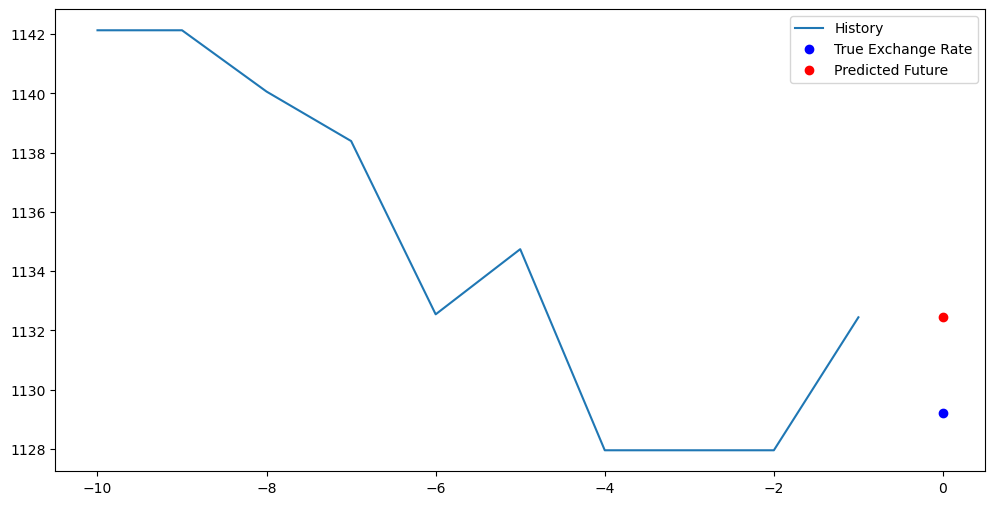

1/1 [==============================] - 0s 23ms/step


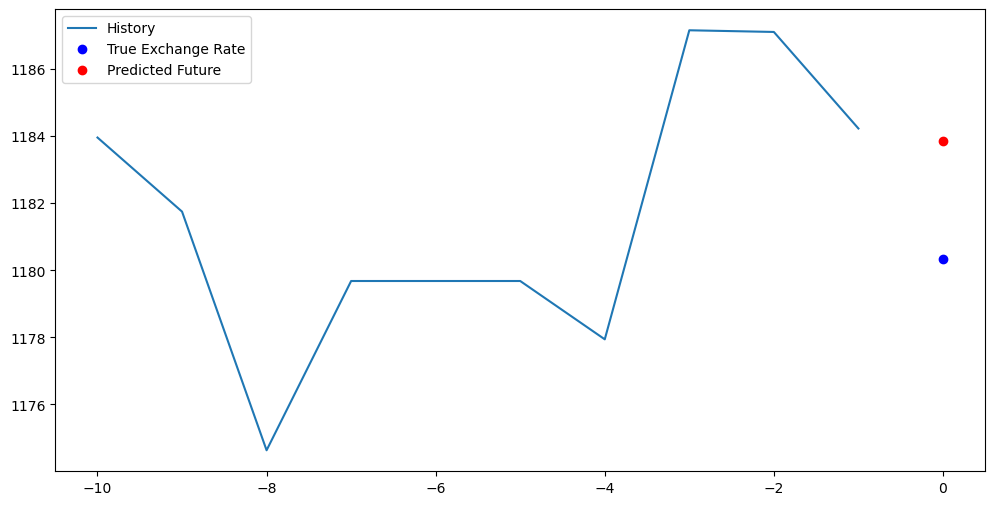

1/1 [==============================] - 0s 16ms/step


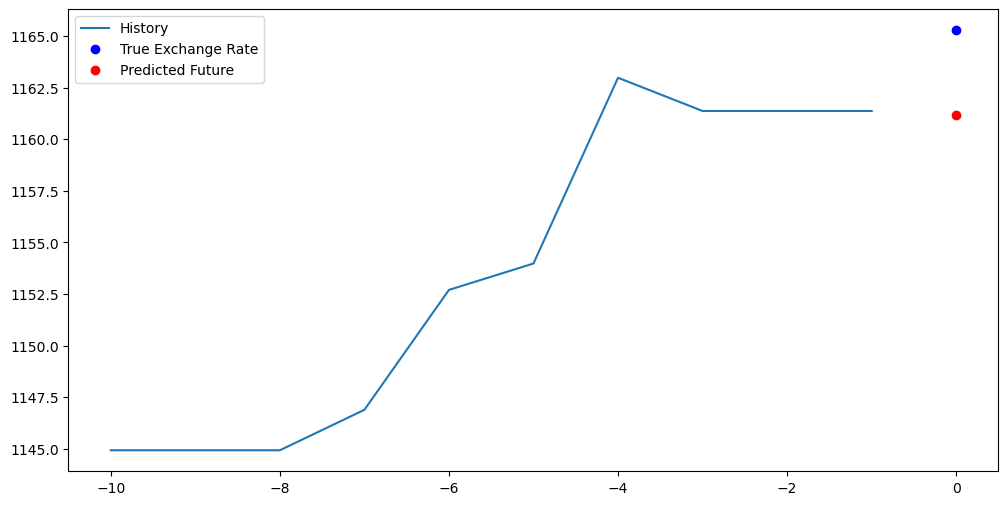

1/1 [==============================] - 0s 31ms/step


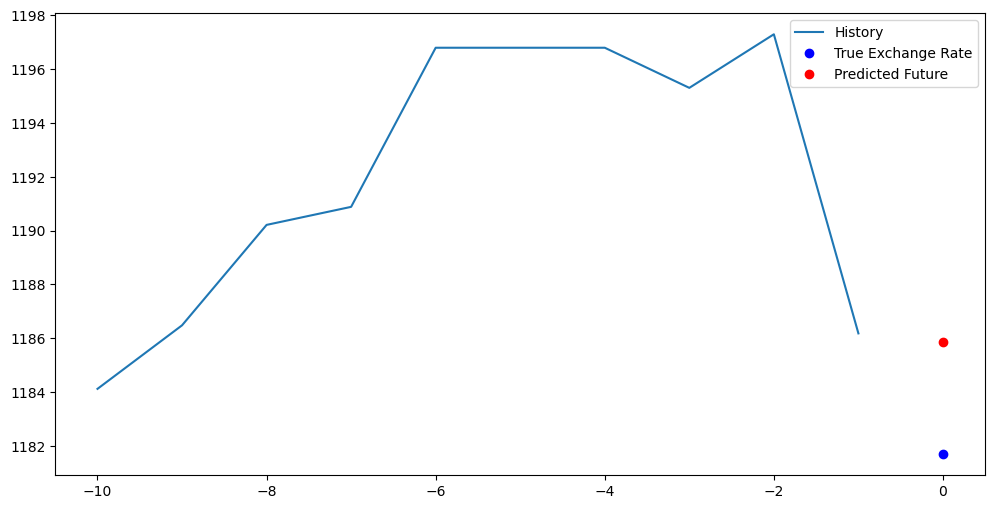

1/1 [==============================] - 0s 27ms/step


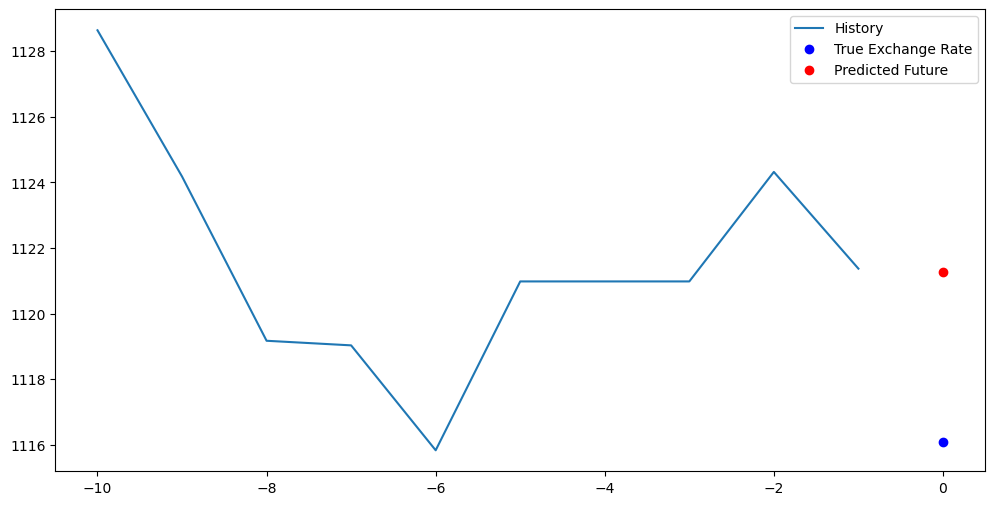

1/1 [==============================] - 0s 24ms/step


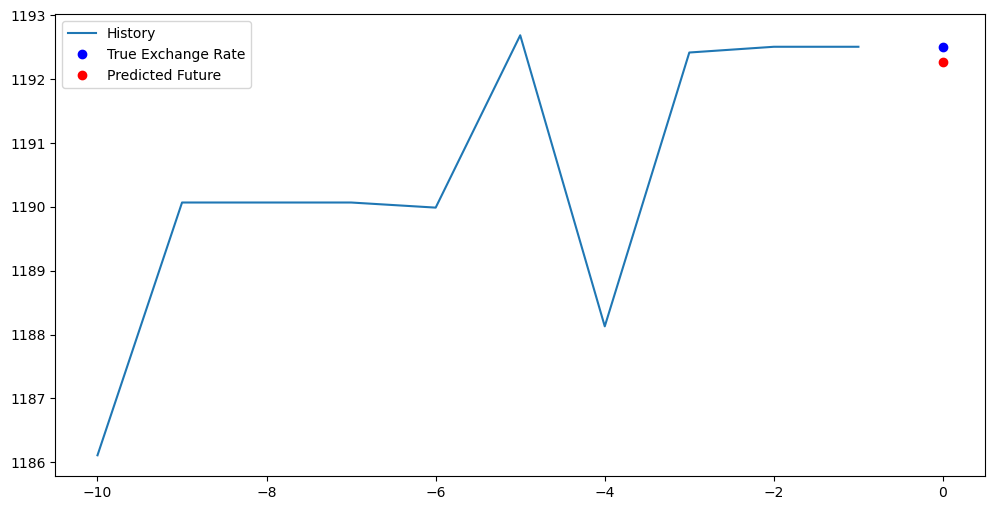

1/1 [==============================] - 0s 20ms/step


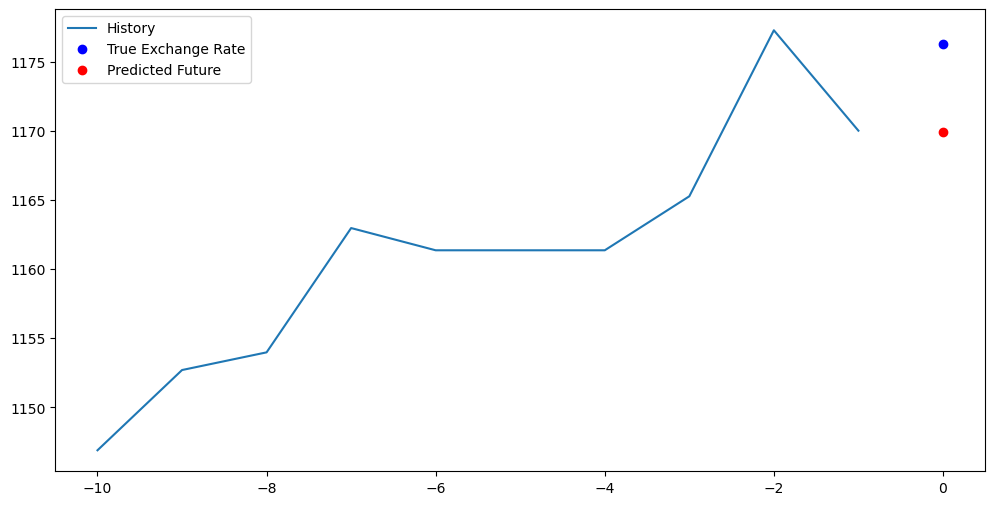

1/1 [==============================] - 0s 21ms/step


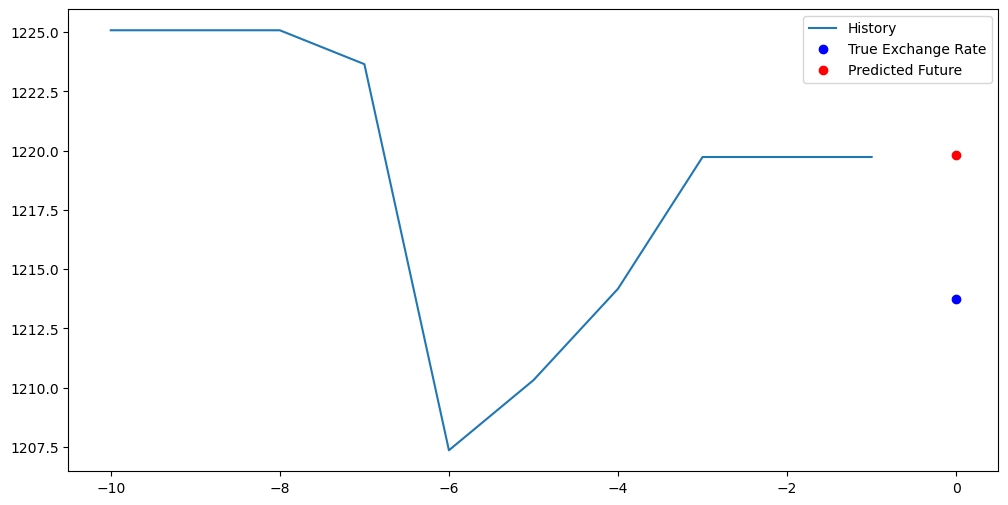

1/1 [==============================] - 0s 18ms/step


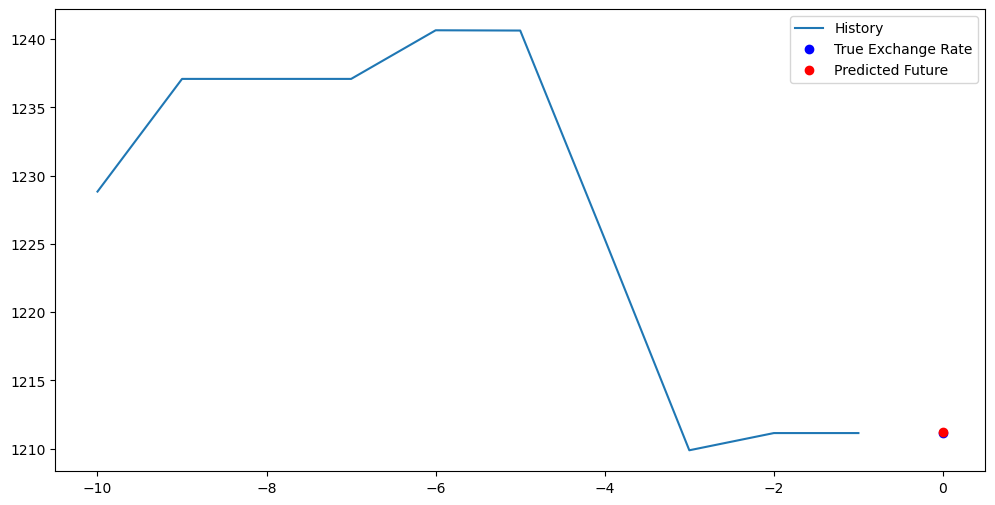

1/1 [==============================] - 0s 20ms/step


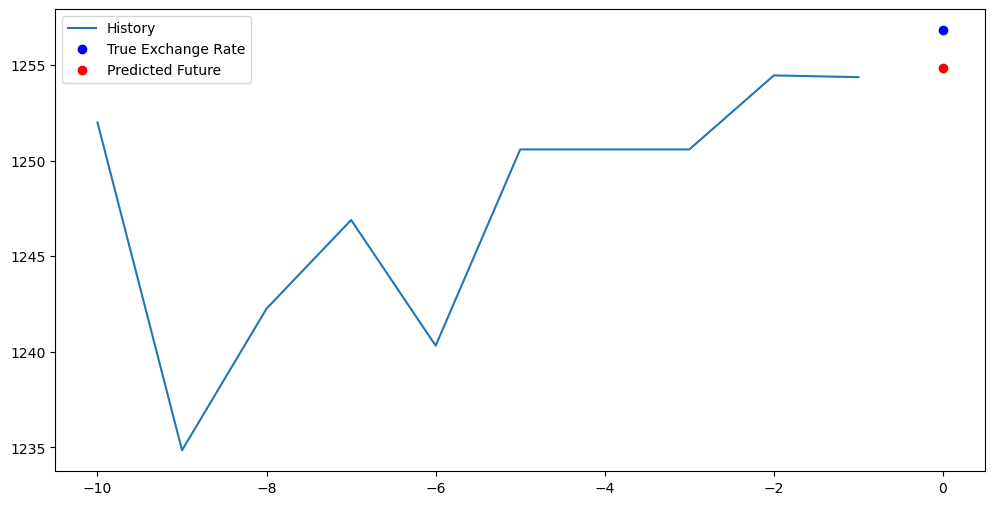

1/1 [==============================] - 0s 22ms/step


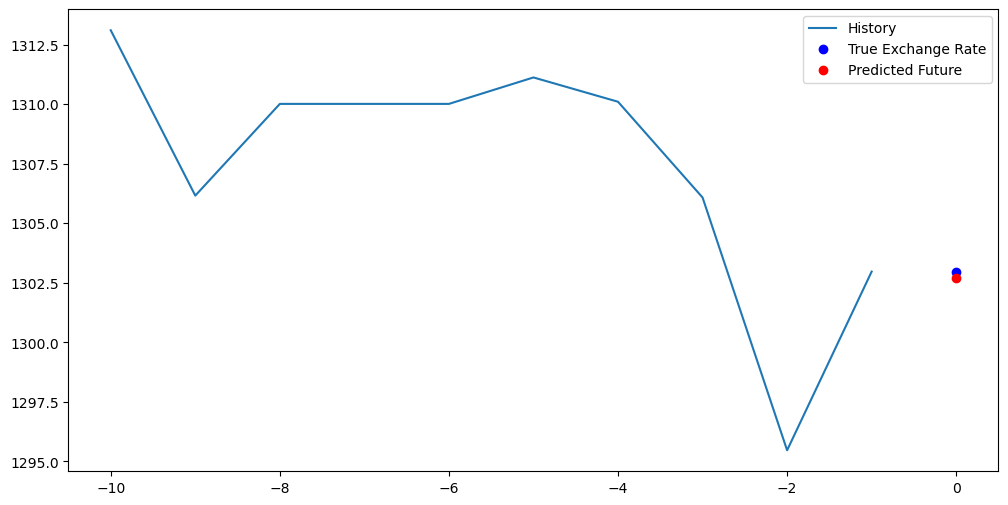

1/1 [==============================] - 0s 21ms/step


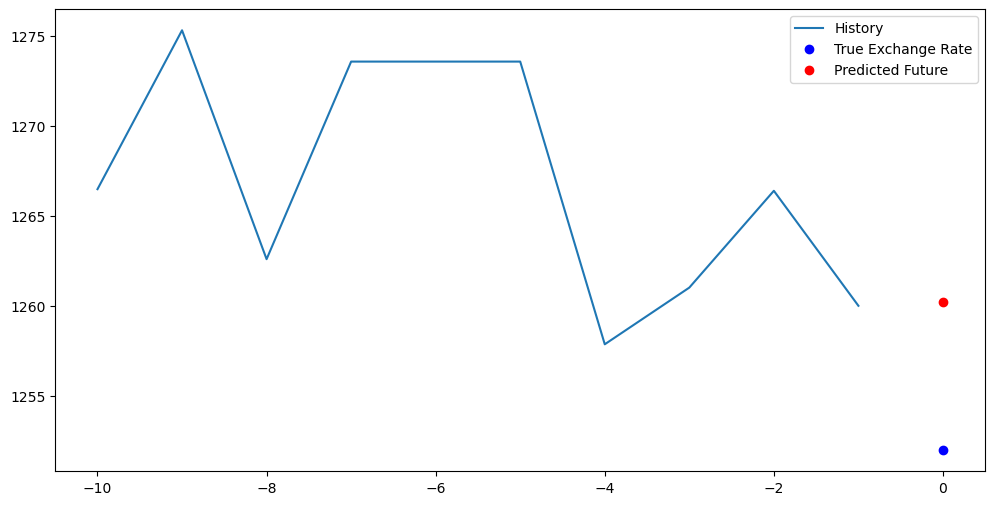

1/1 [==============================] - 0s 22ms/step


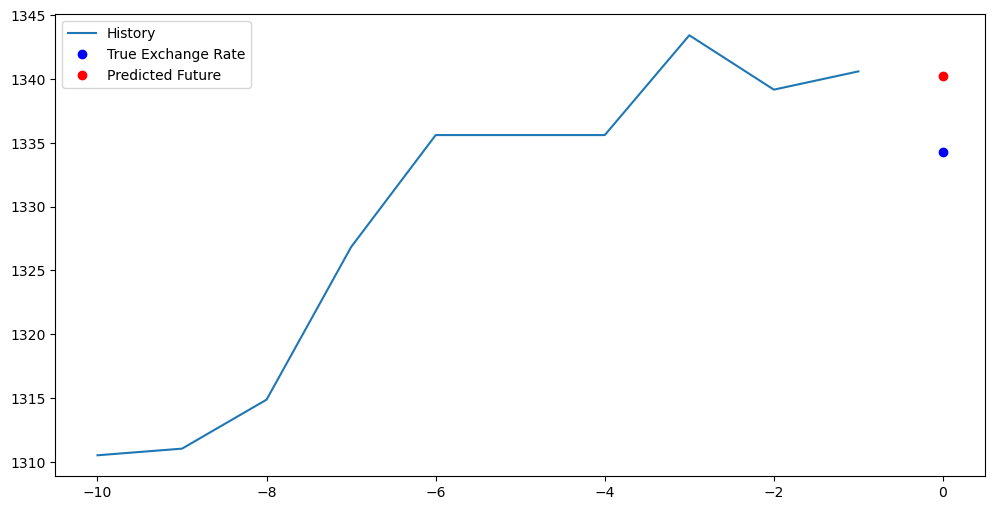

1/1 [==============================] - 0s 45ms/step


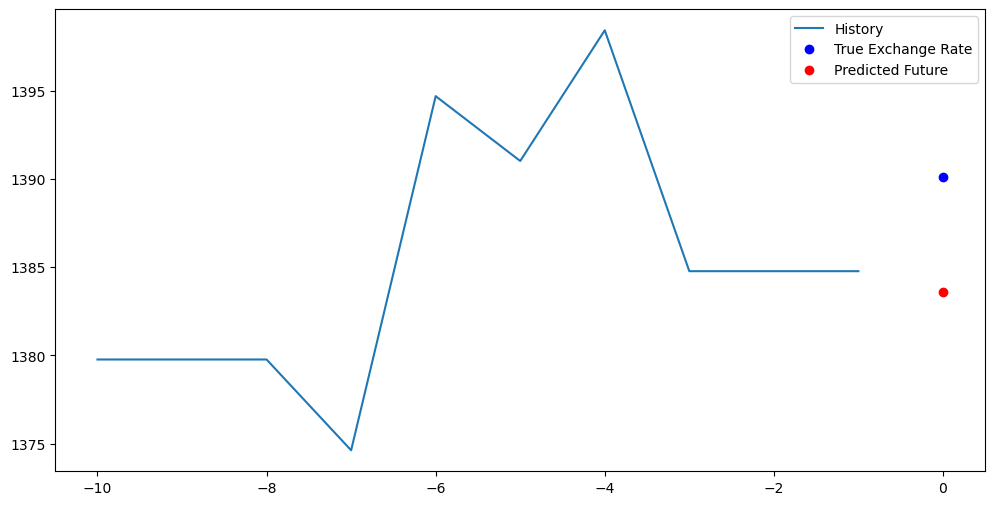

1/1 [==============================] - 0s 21ms/step


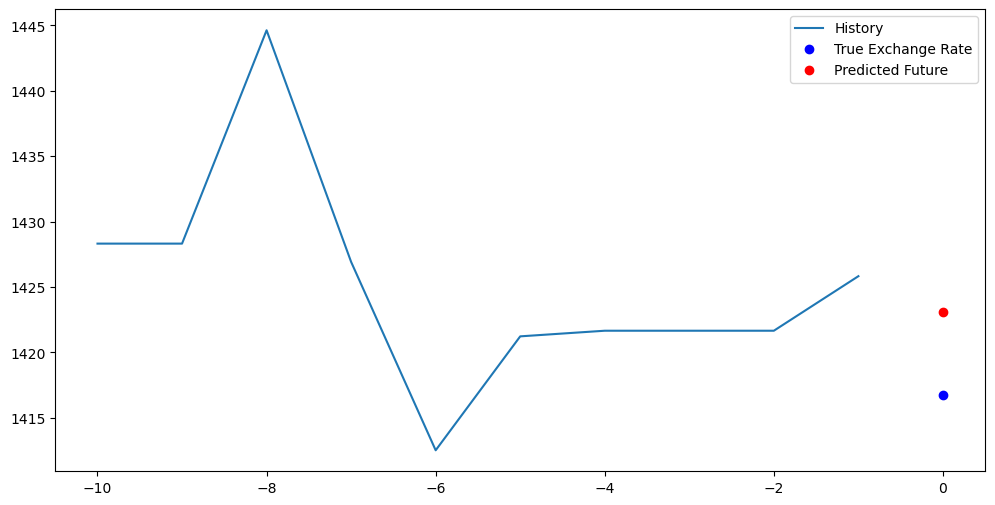

1/1 [==============================] - 0s 22ms/step


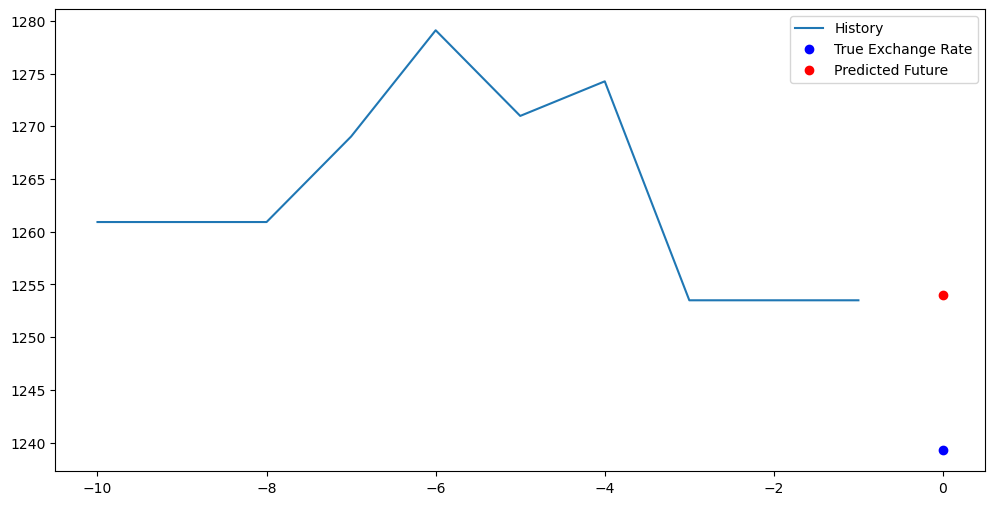

1/1 [==============================] - 0s 30ms/step


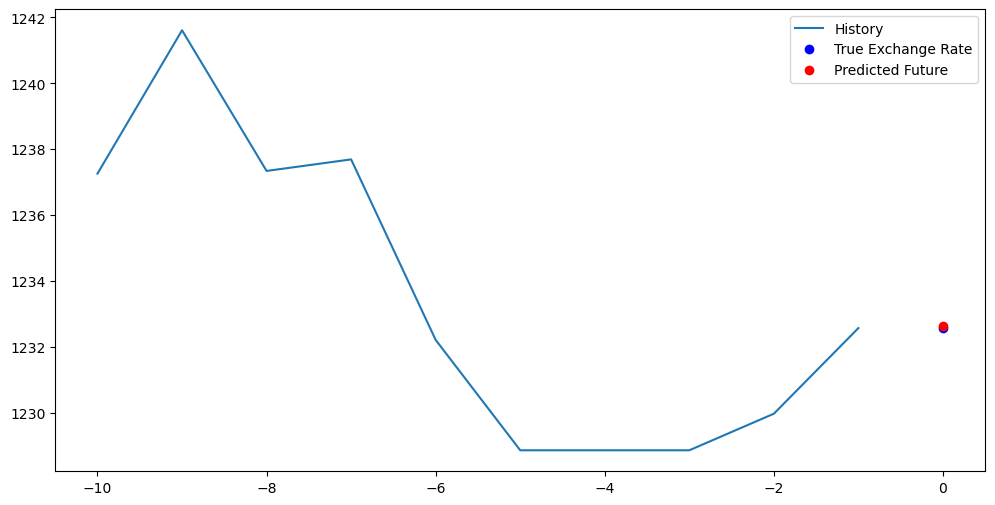

1/1 [==============================] - 0s 16ms/step


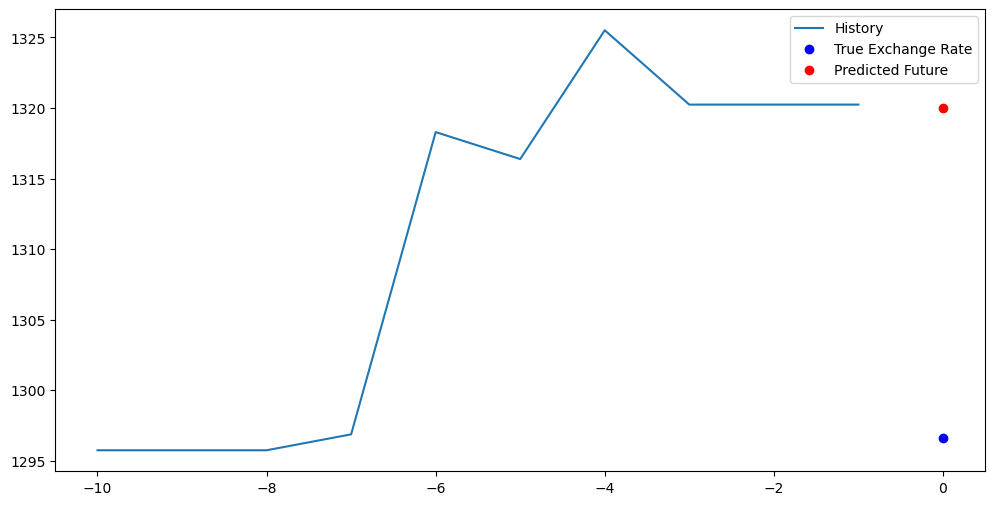

1/1 [==============================] - 0s 31ms/step


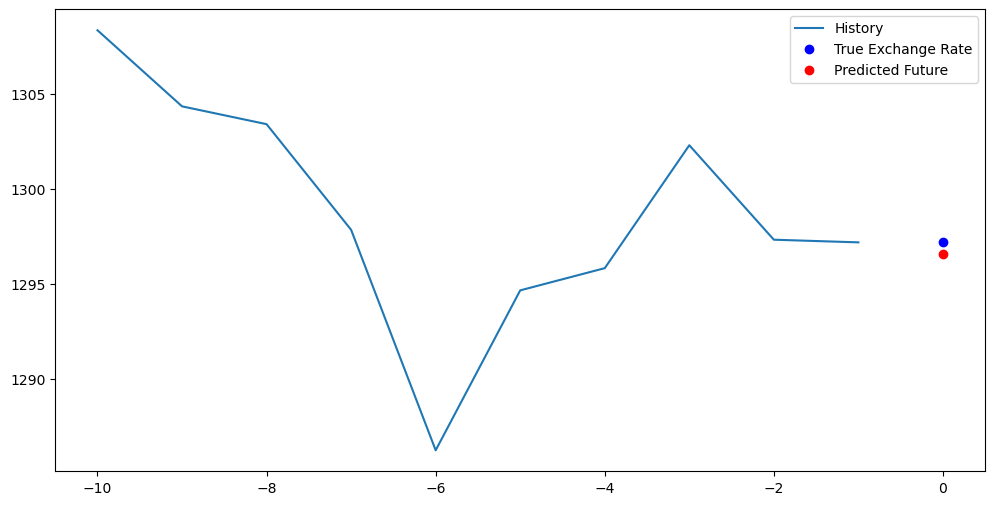

1/1 [==============================] - 0s 355ms/step


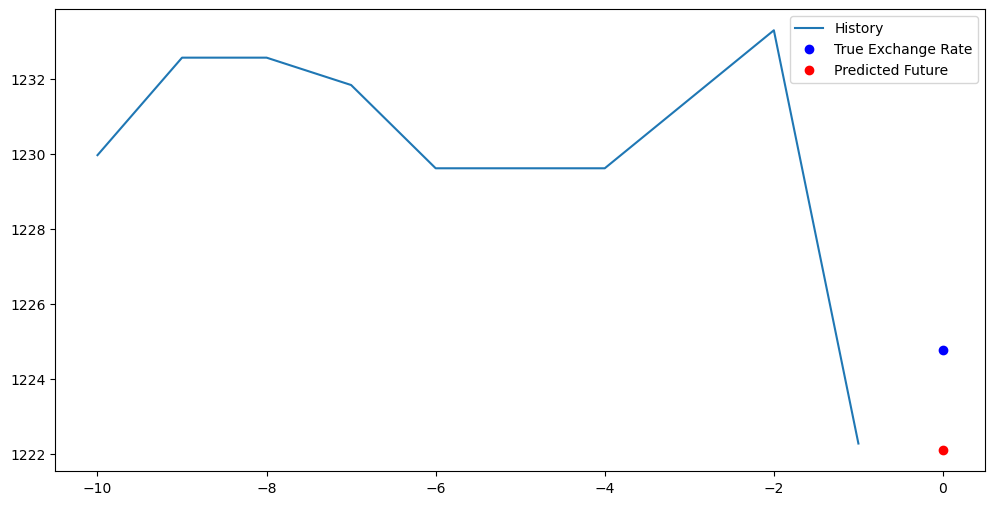

1/1 [==============================] - 0s 31ms/step


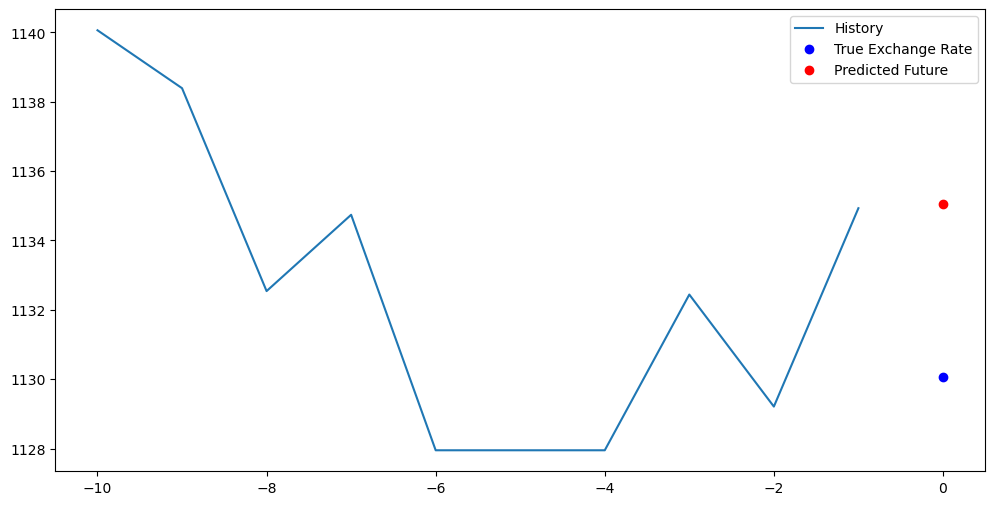

1/1 [==============================] - 0s 28ms/step


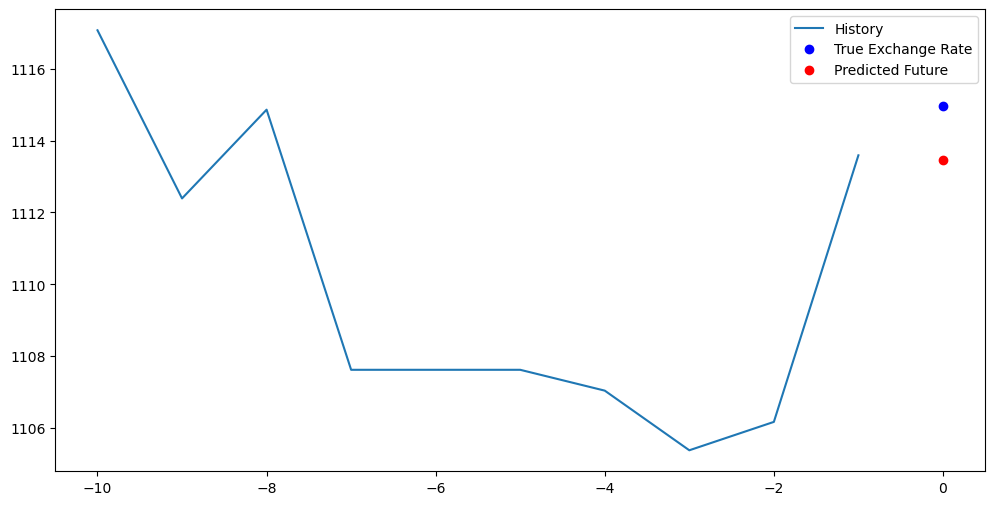

1/1 [==============================] - 0s 30ms/step


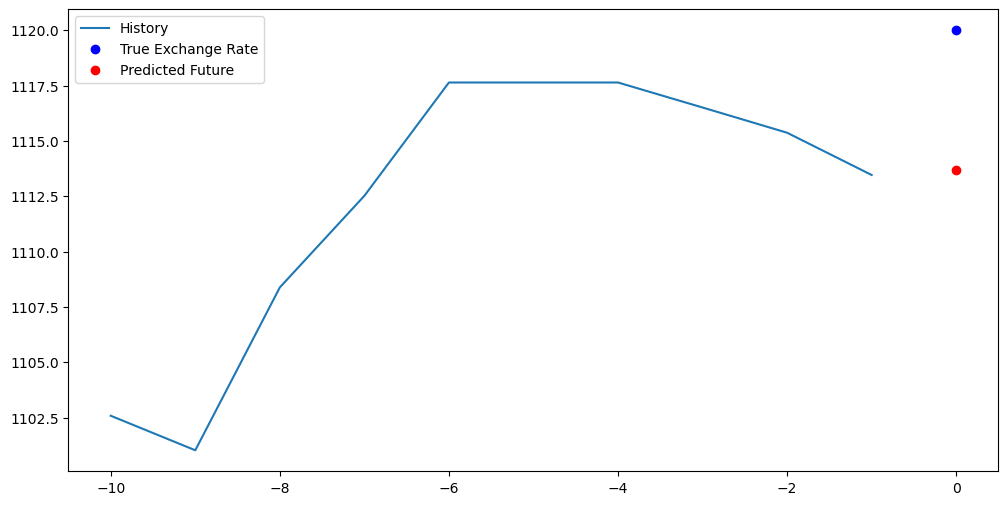

1/1 [==============================] - 0s 31ms/step


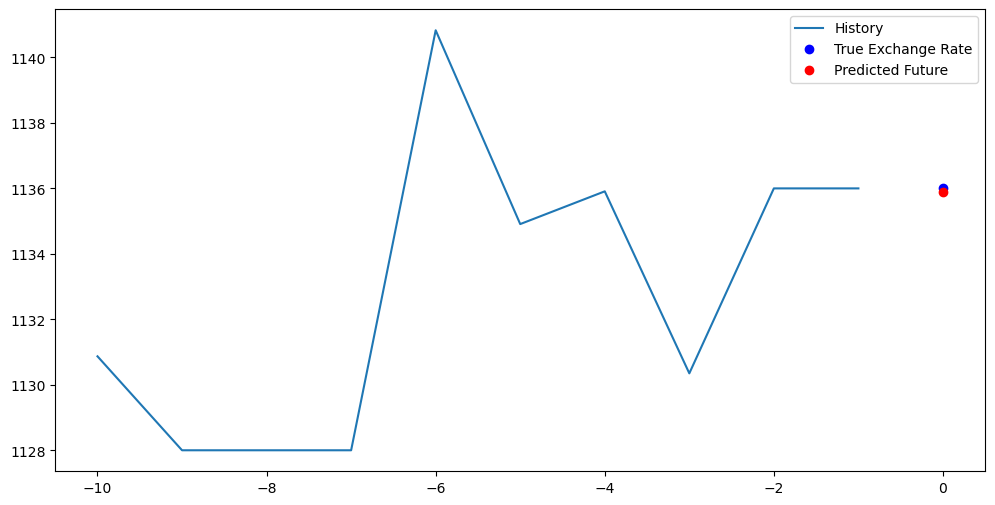

1/1 [==============================] - 0s 17ms/step


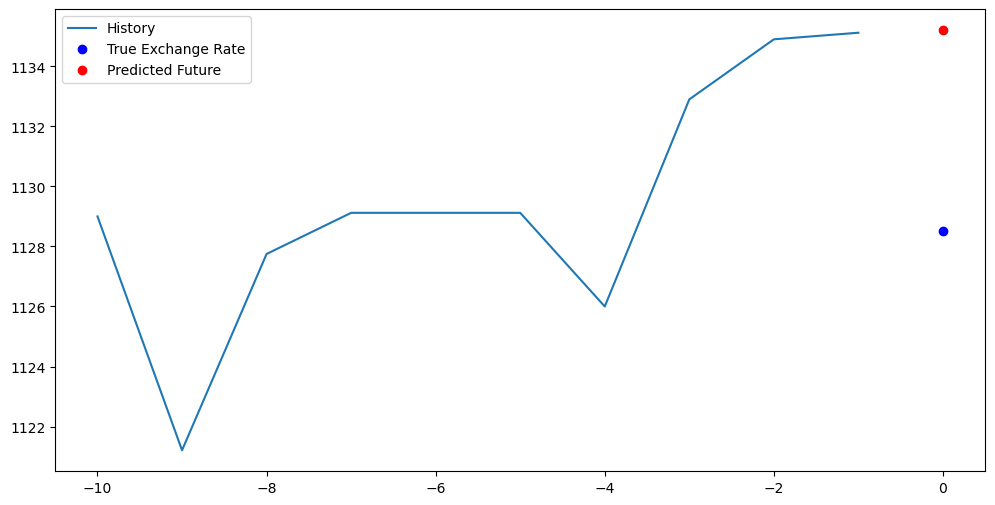

1/1 [==============================] - 0s 38ms/step


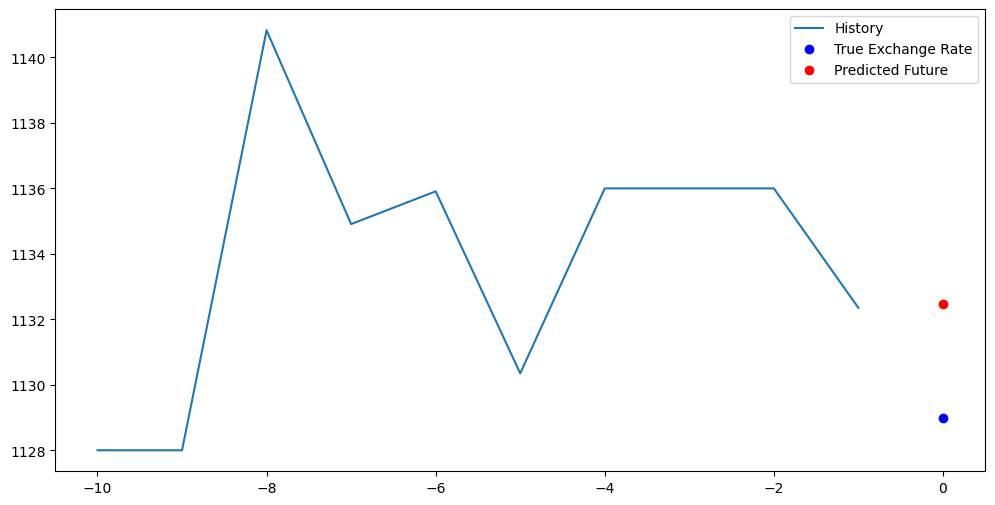

1/1 [==============================] - 0s 24ms/step


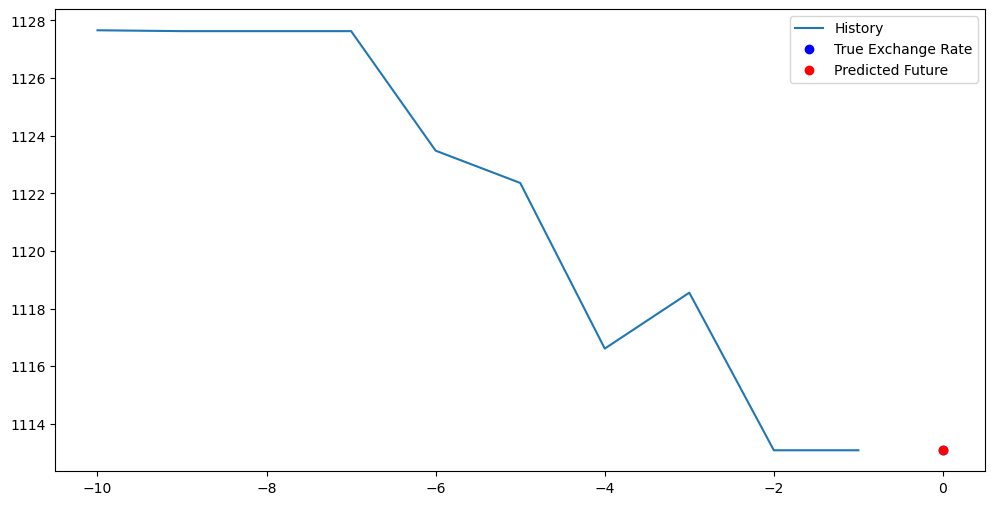

1/1 [==============================] - 0s 19ms/step


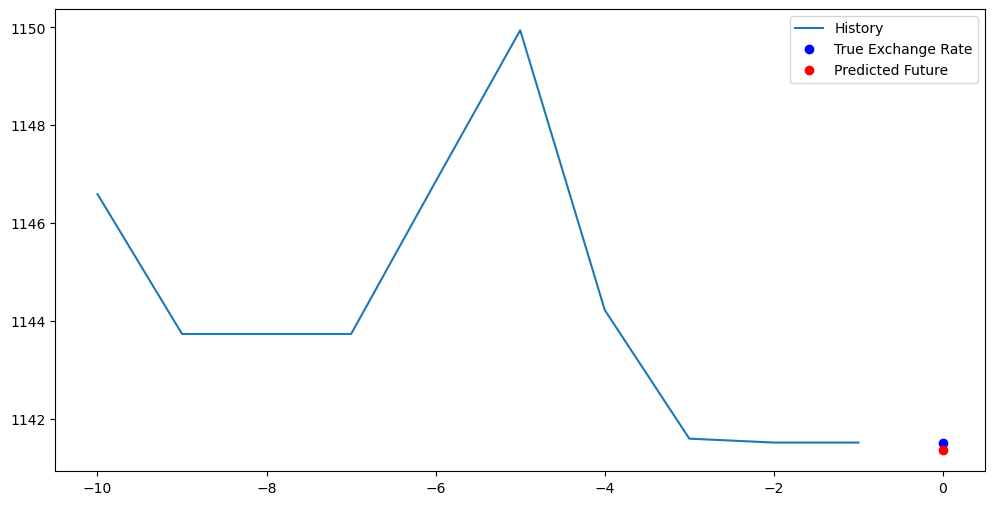

1/1 [==============================] - 0s 16ms/step


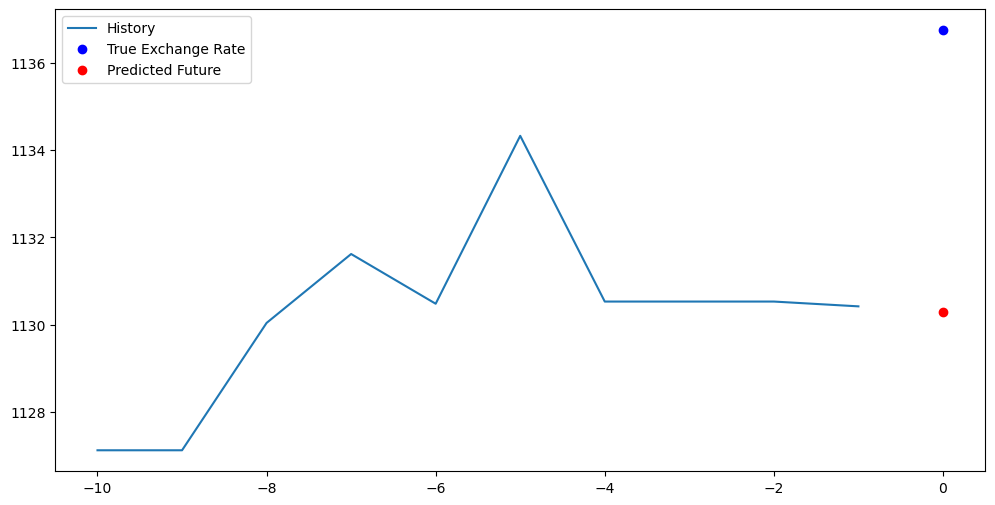

1/1 [==============================] - 0s 32ms/step


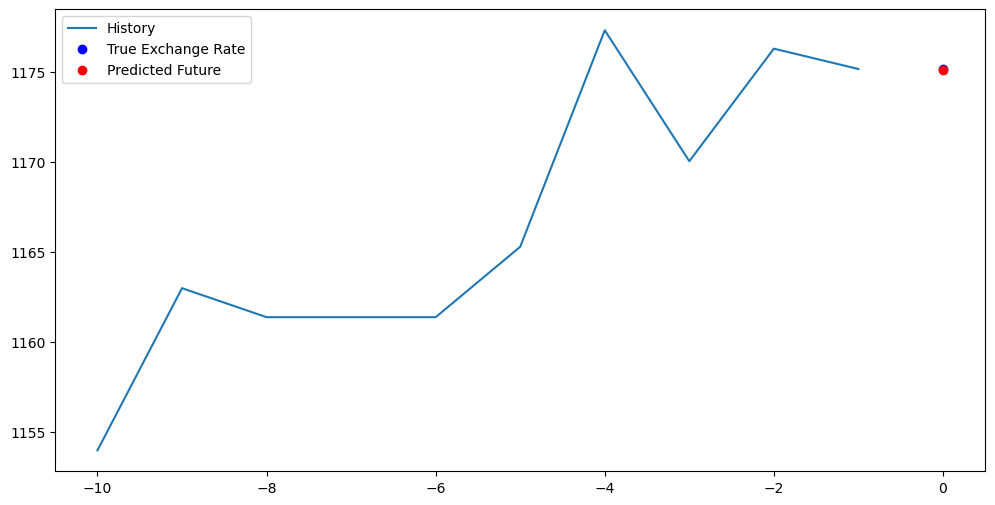

1/1 [==============================] - 0s 37ms/step


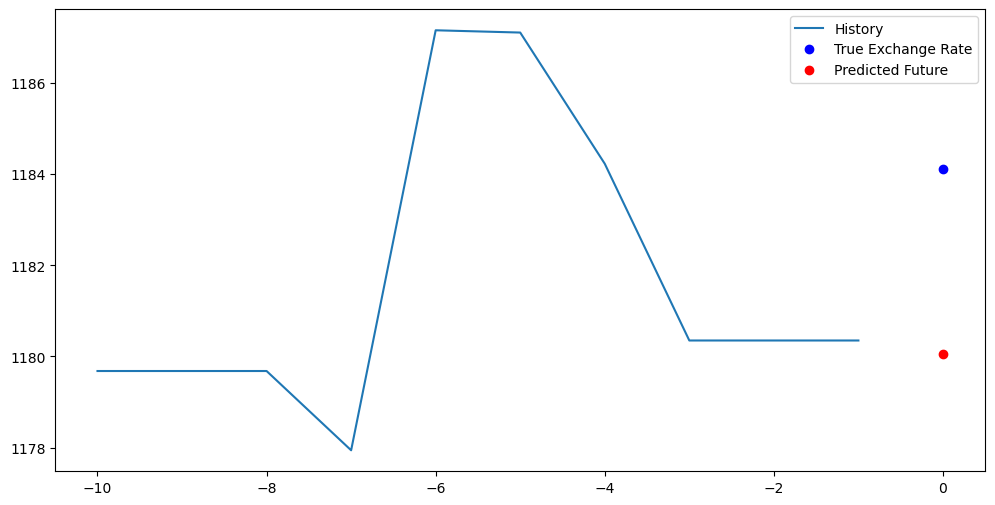

1/1 [==============================] - 0s 33ms/step


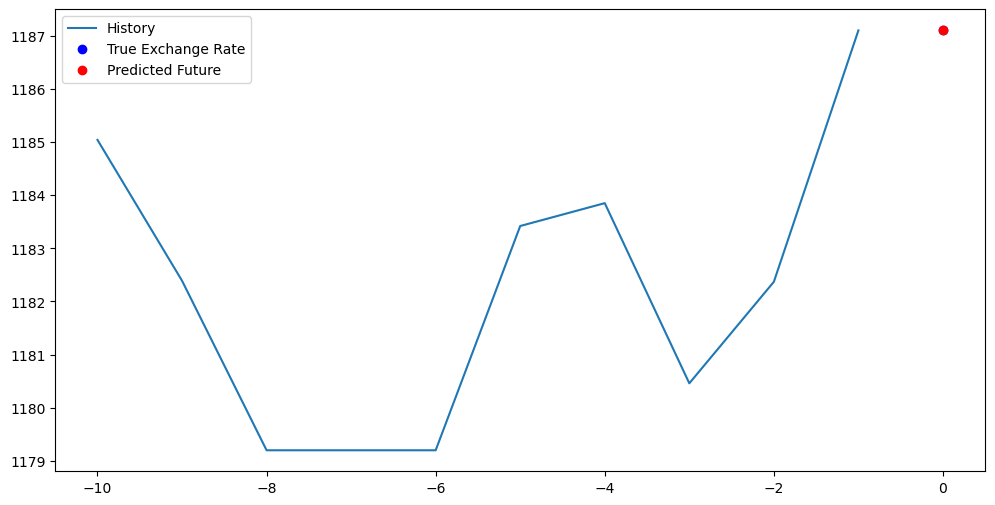

1/1 [==============================] - 0s 29ms/step


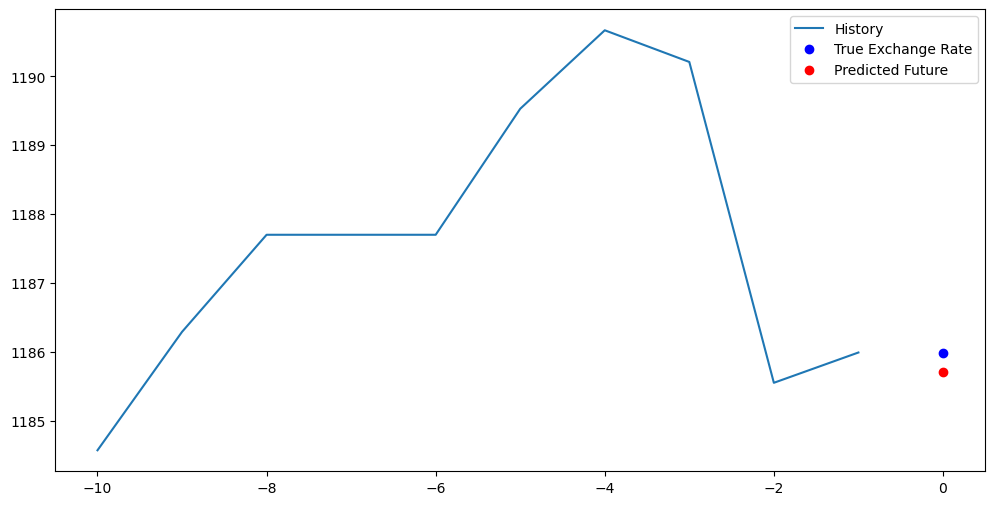

1/1 [==============================] - 0s 16ms/step


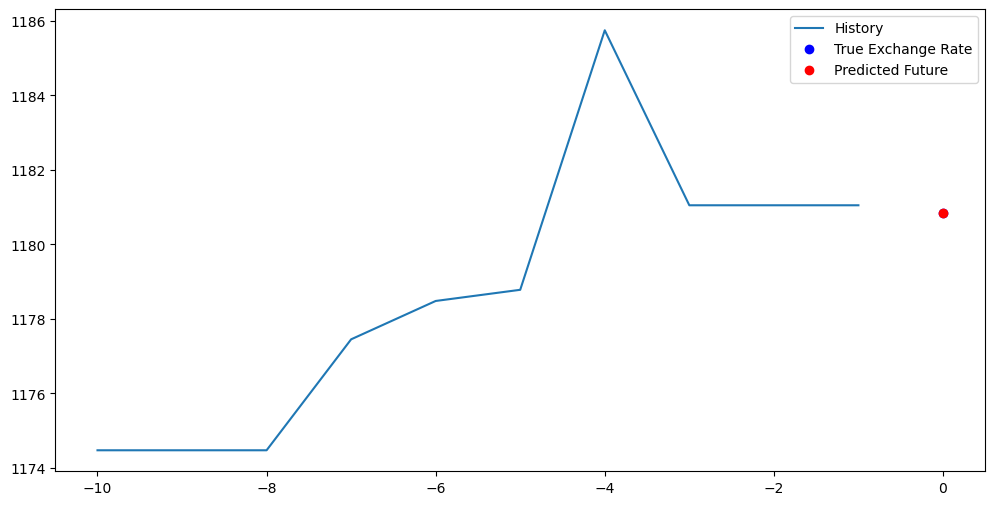

1/1 [==============================] - 0s 21ms/step


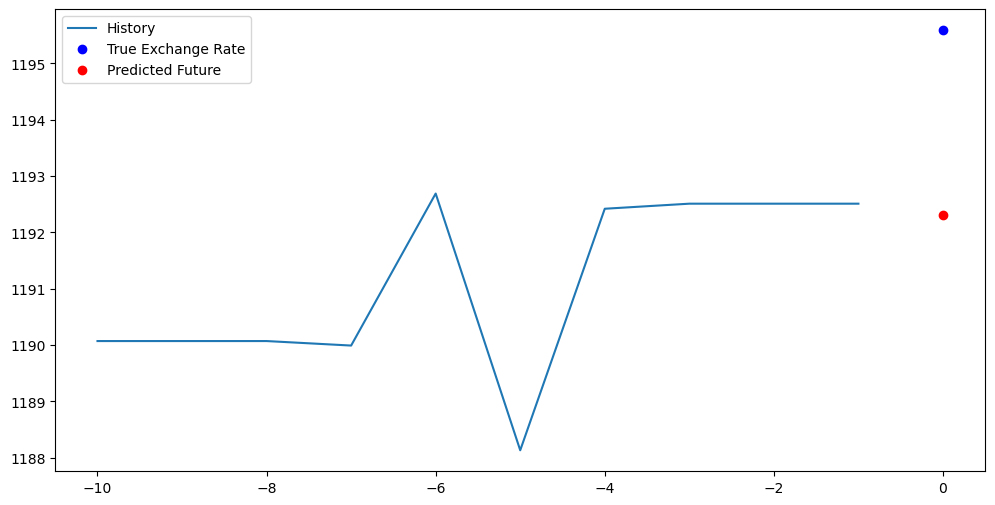

1/1 [==============================] - 0s 25ms/step


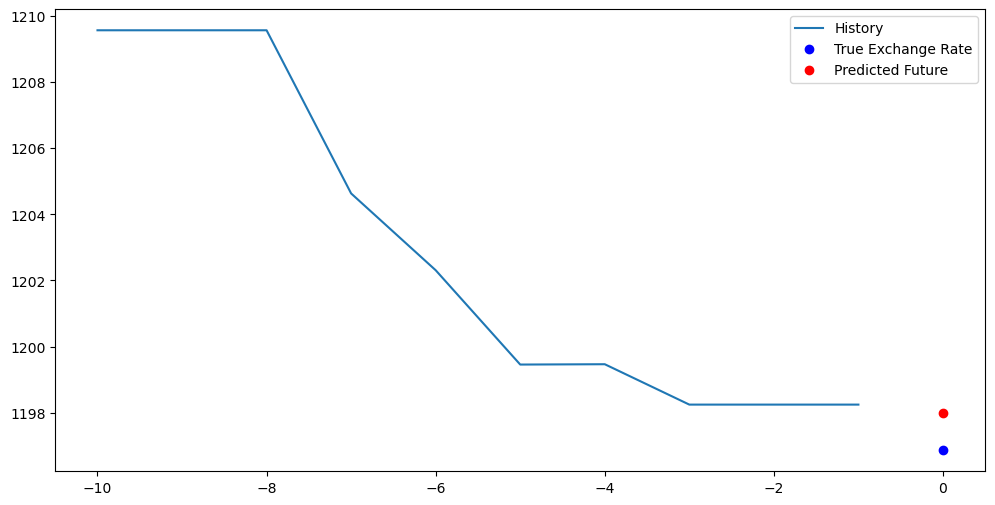

1/1 [==============================] - 0s 20ms/step


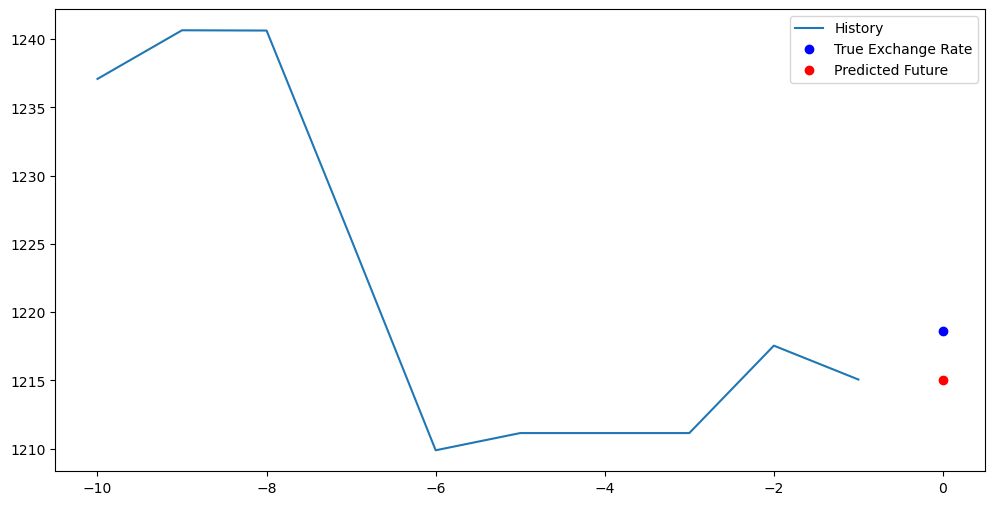

1/1 [==============================] - 0s 34ms/step


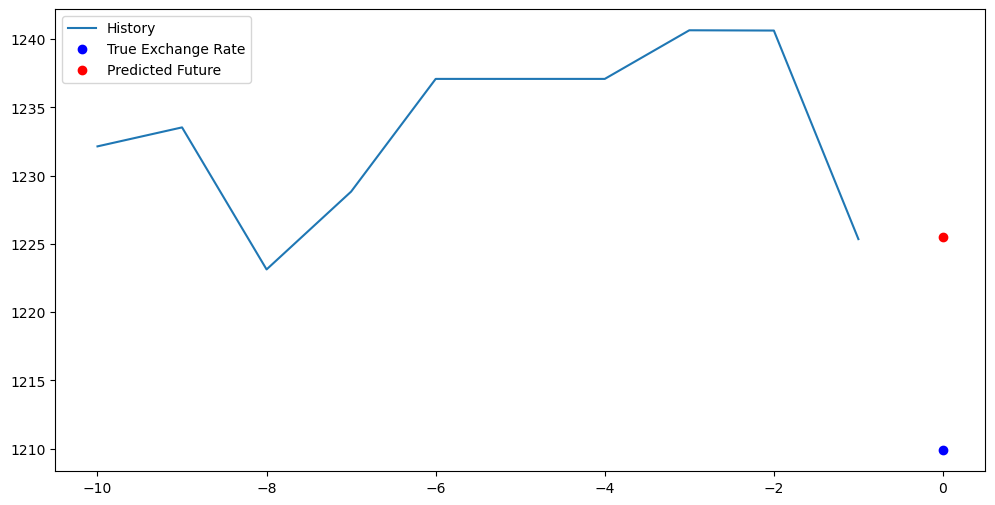

1/1 [==============================] - 0s 21ms/step


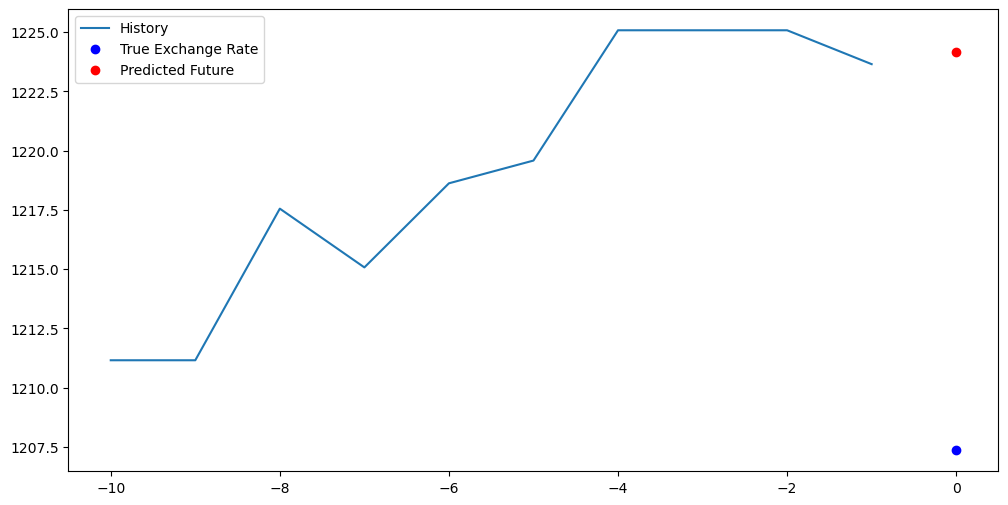

1/1 [==============================] - 0s 26ms/step


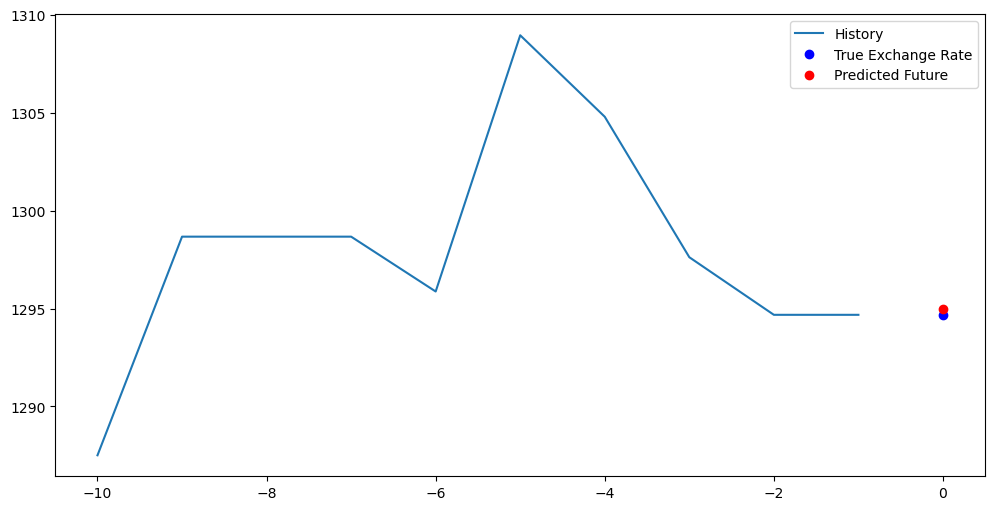

1/1 [==============================] - 0s 20ms/step


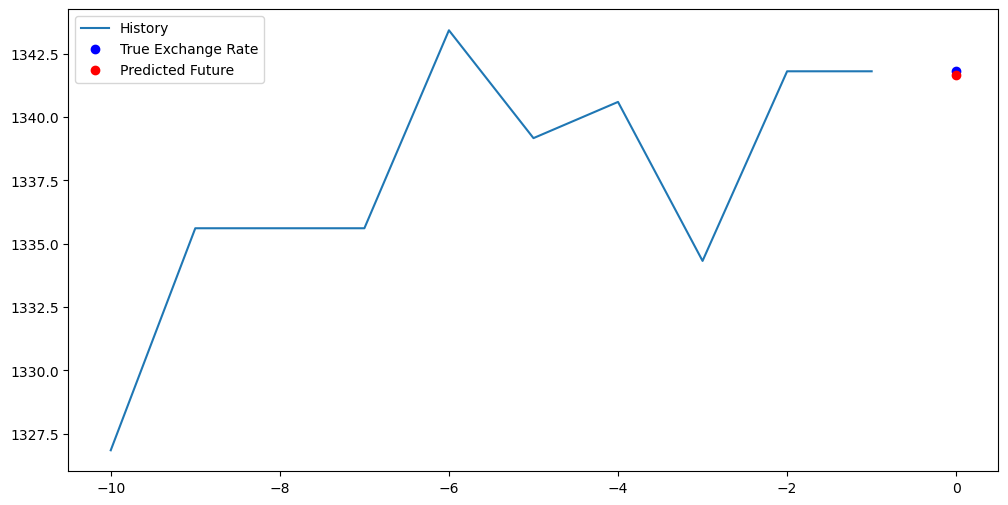

1/1 [==============================] - 0s 21ms/step


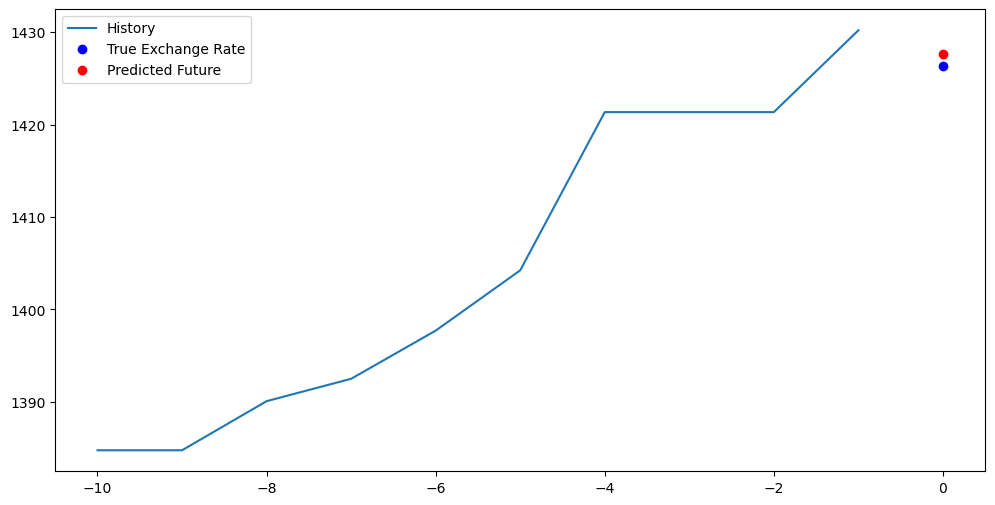

1/1 [==============================] - 0s 39ms/step


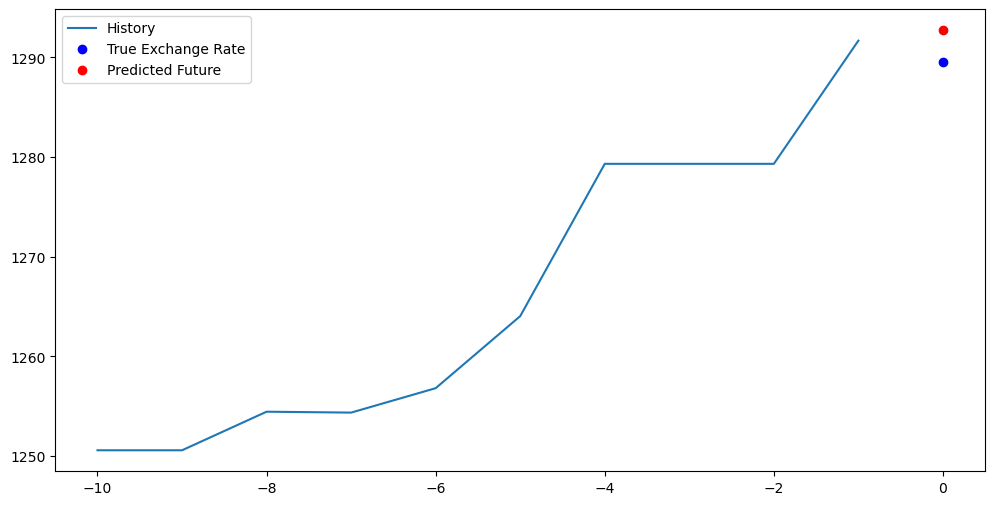

1/1 [==============================] - 0s 33ms/step


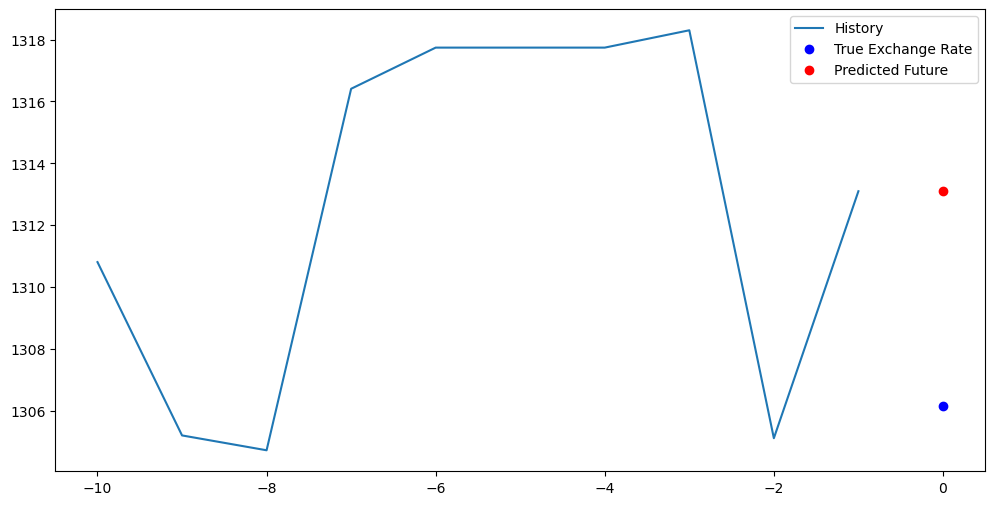

1/1 [==============================] - 0s 36ms/step


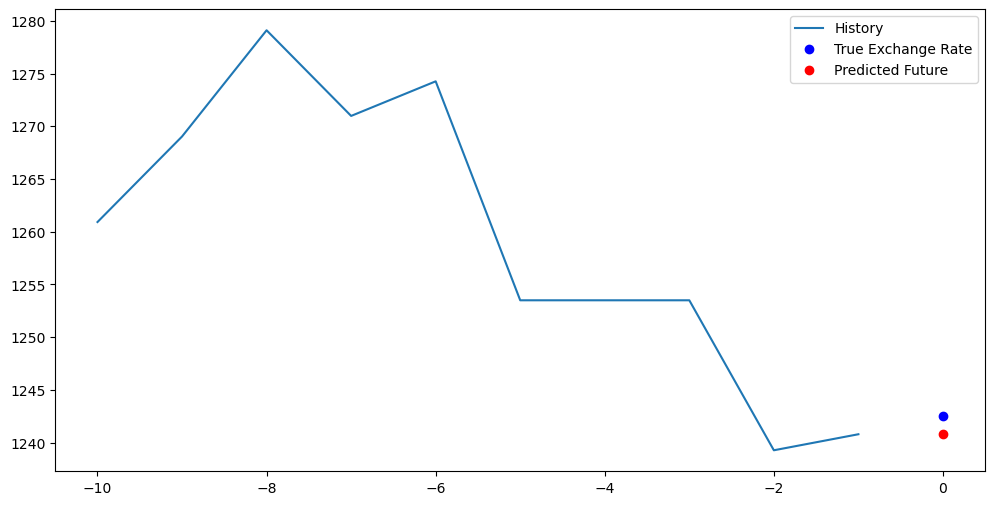

1/1 [==============================] - 0s 19ms/step


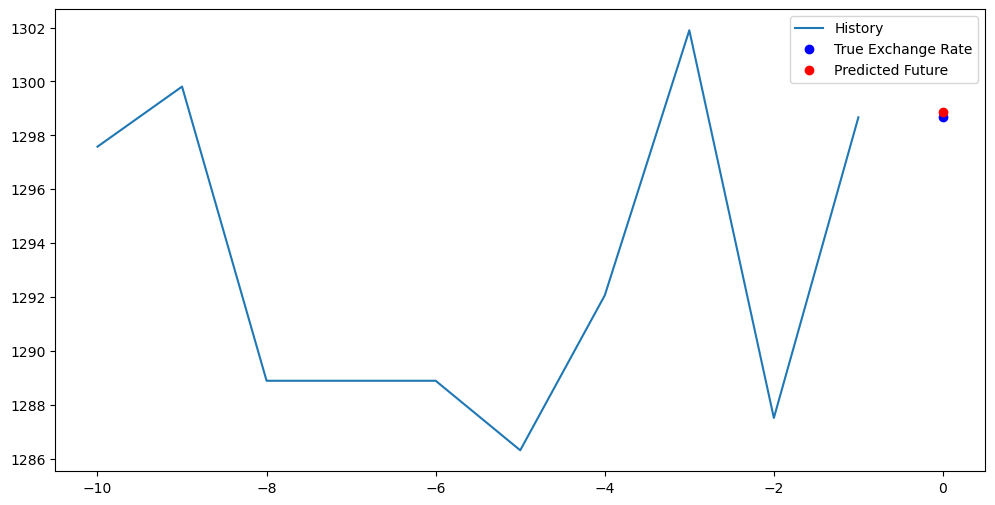

1/1 [==============================] - 0s 17ms/step


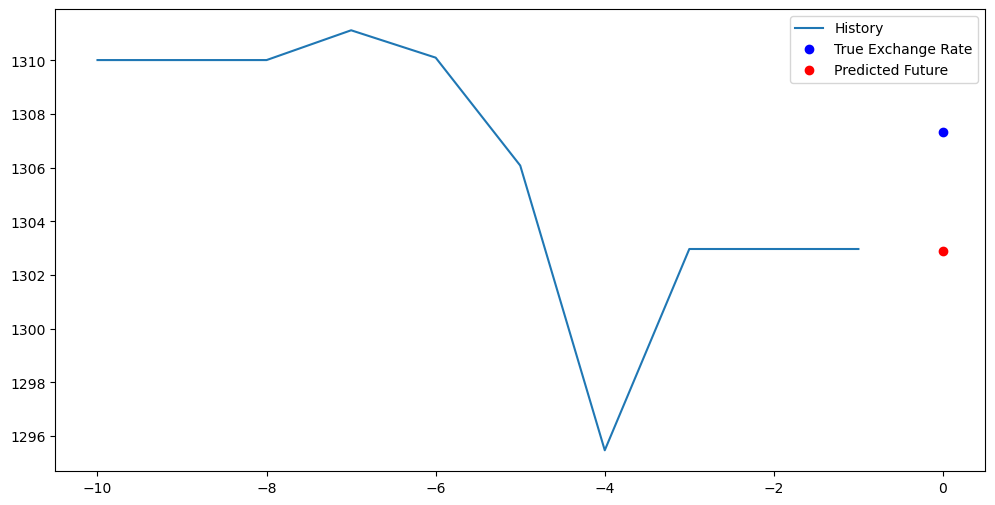

1/1 [==============================] - 0s 21ms/step


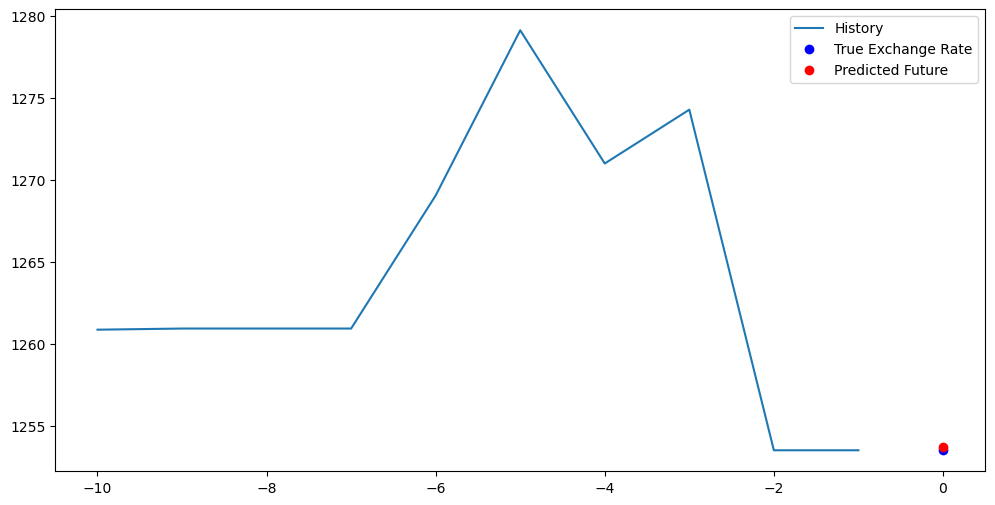

1/1 [==============================] - 0s 21ms/step


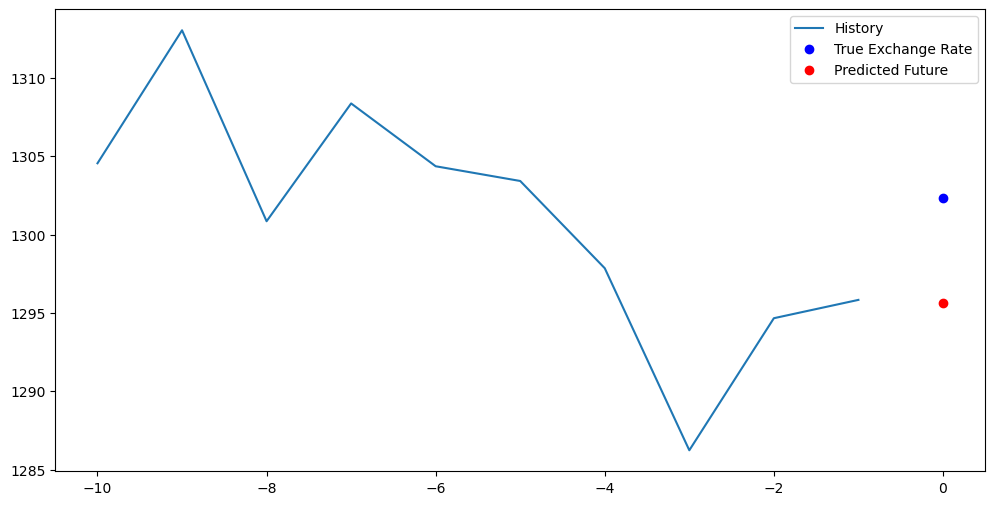

1/1 [==============================] - 0s 32ms/step


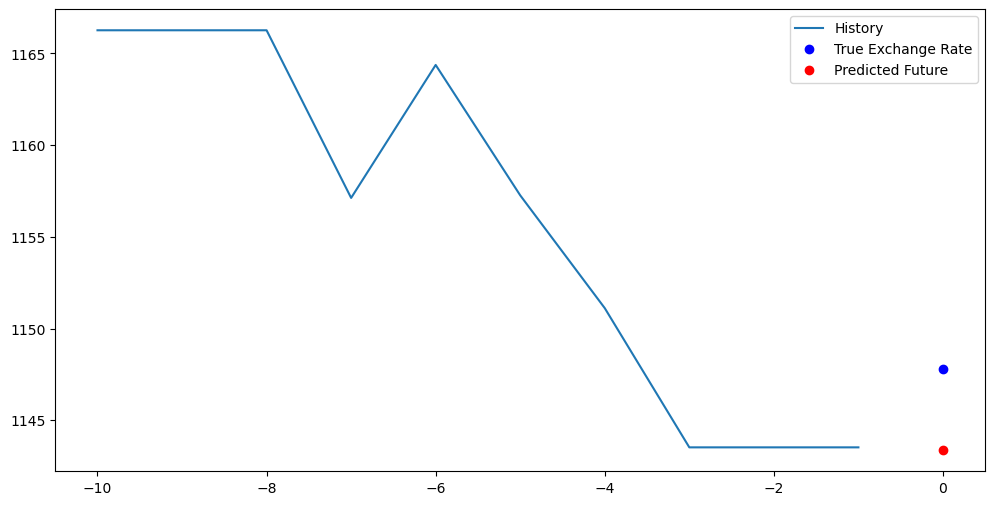

1/1 [==============================] - 0s 16ms/step


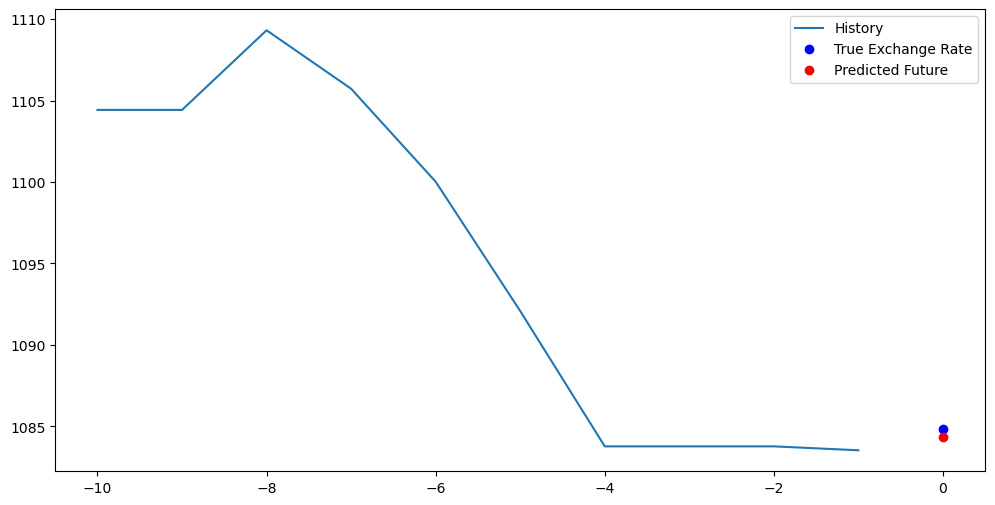

1/1 [==============================] - 0s 31ms/step


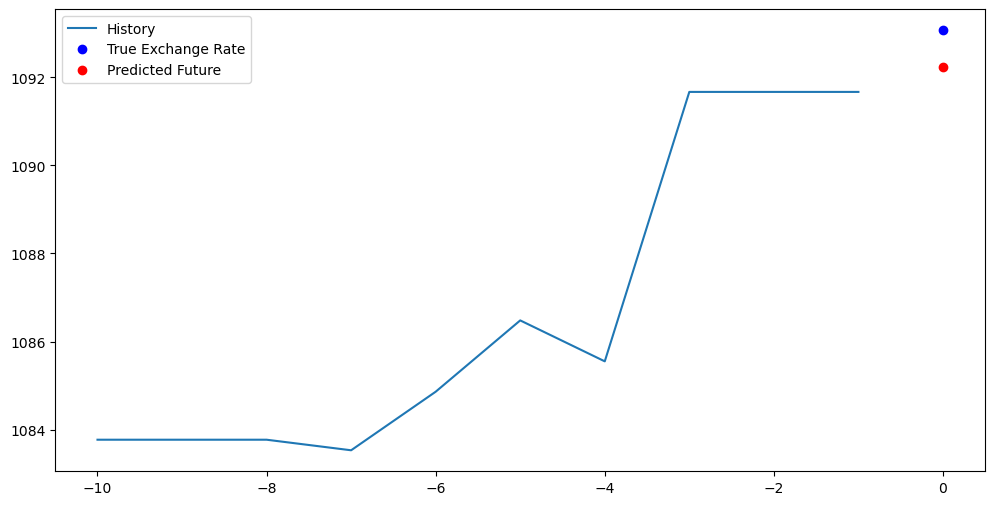

1/1 [==============================] - 0s 21ms/step


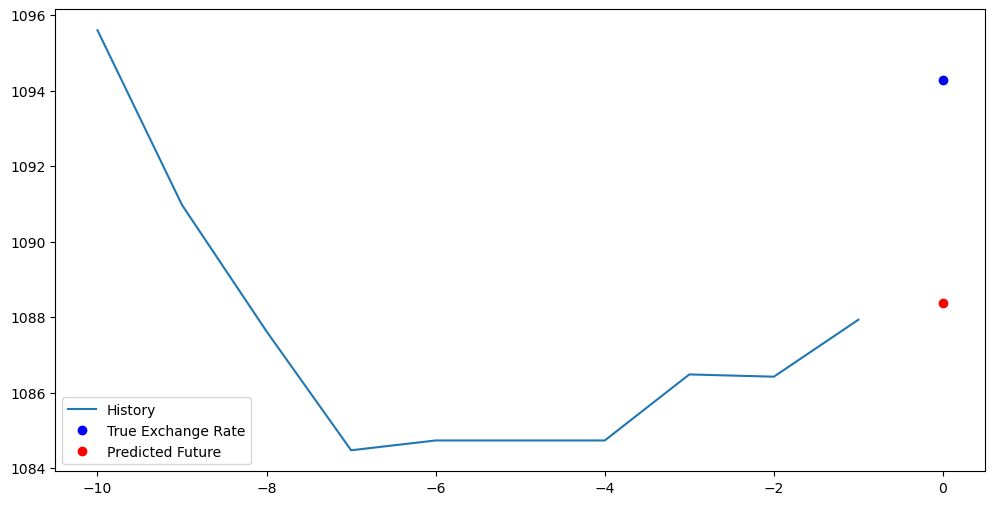

1/1 [==============================] - 0s 48ms/step


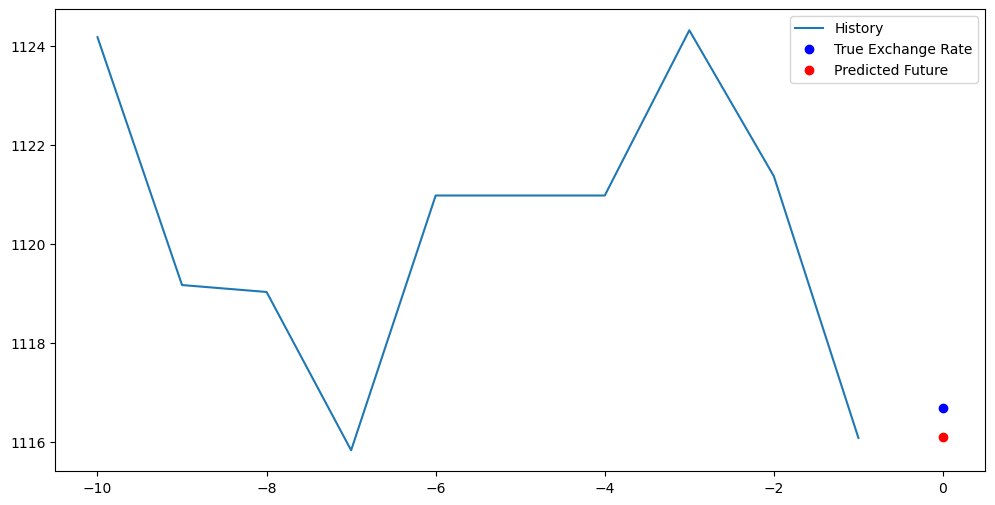

1/1 [==============================] - 0s 17ms/step


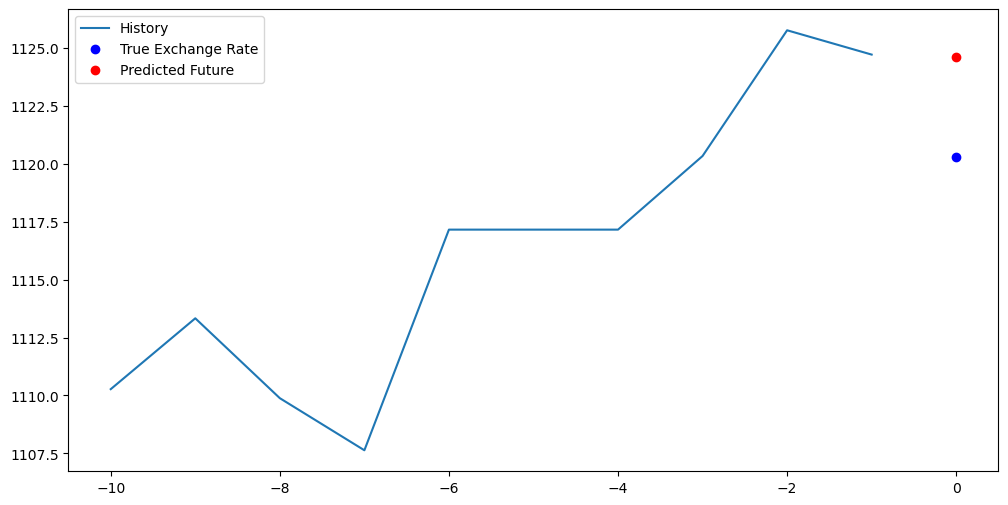

1/1 [==============================] - 0s 16ms/step


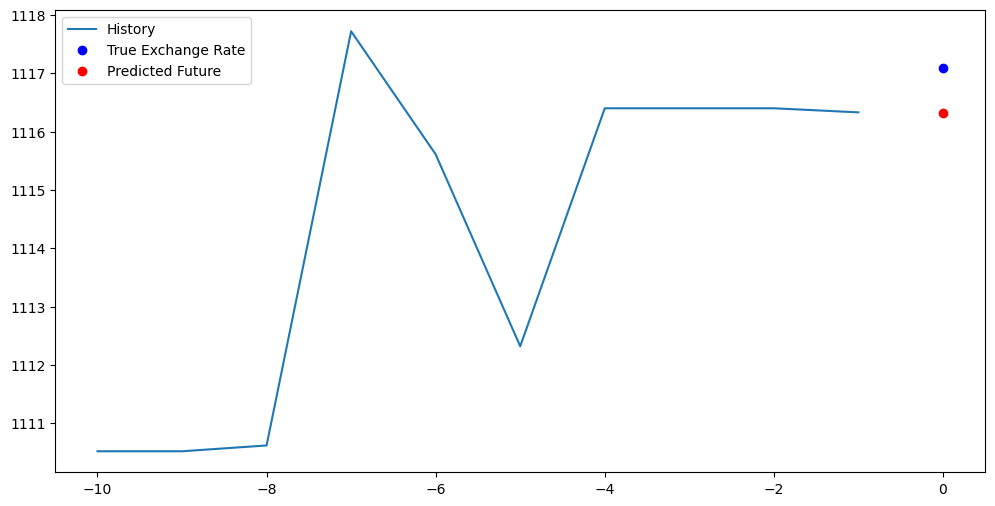

1/1 [==============================] - 0s 48ms/step


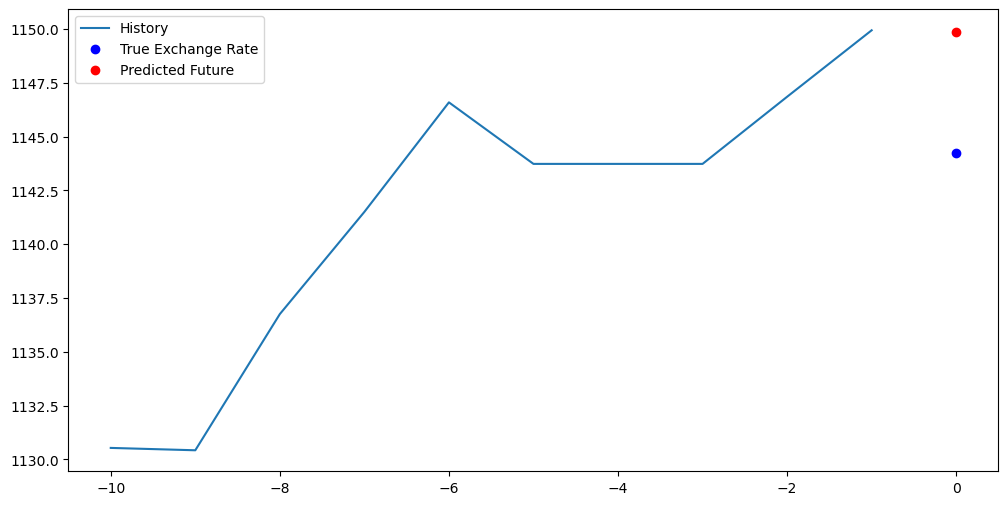

1/1 [==============================] - 0s 16ms/step


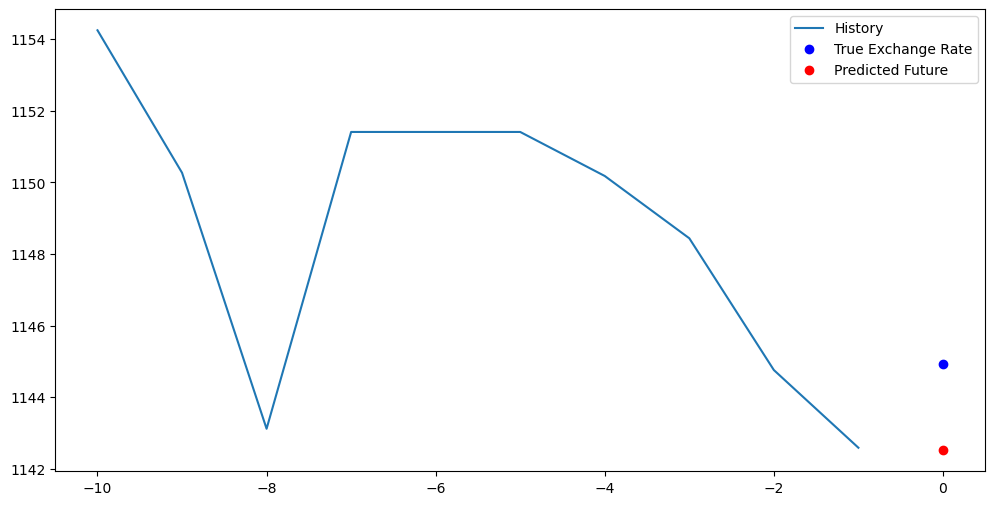

1/1 [==============================] - 0s 38ms/step


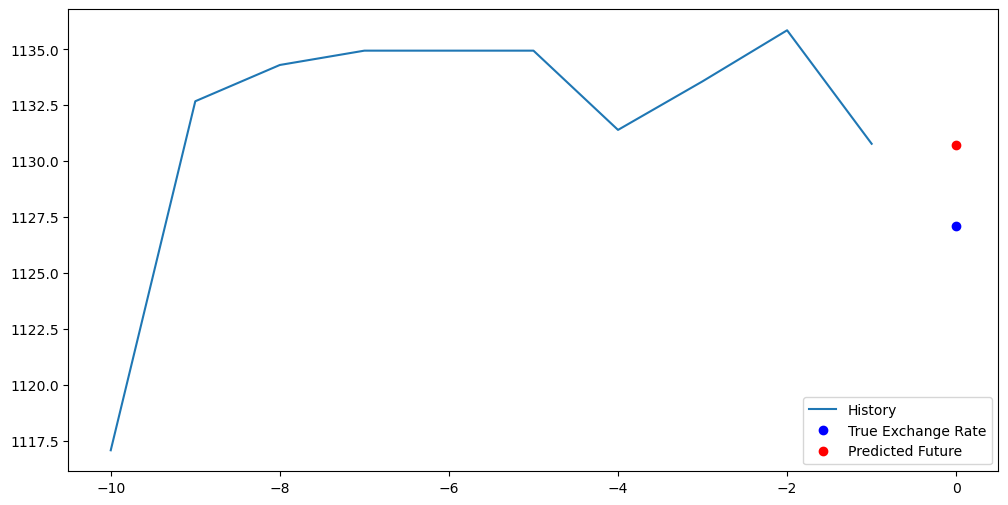

1/1 [==============================] - 0s 21ms/step


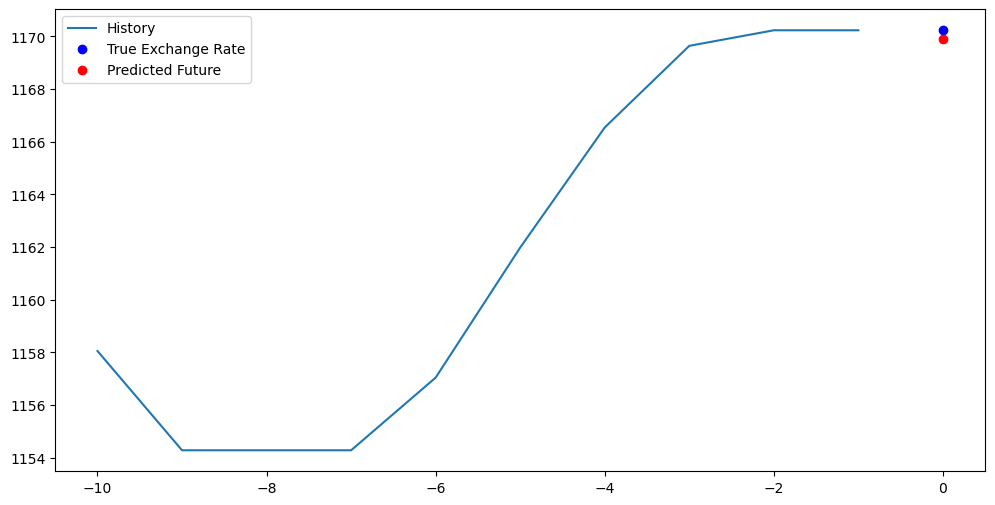

1/1 [==============================] - 0s 36ms/step


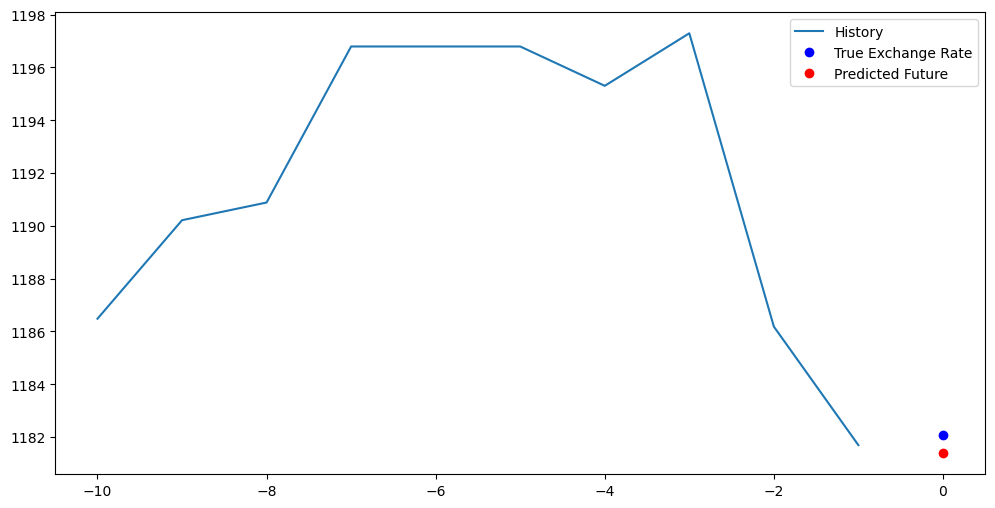

1/1 [==============================] - 0s 22ms/step


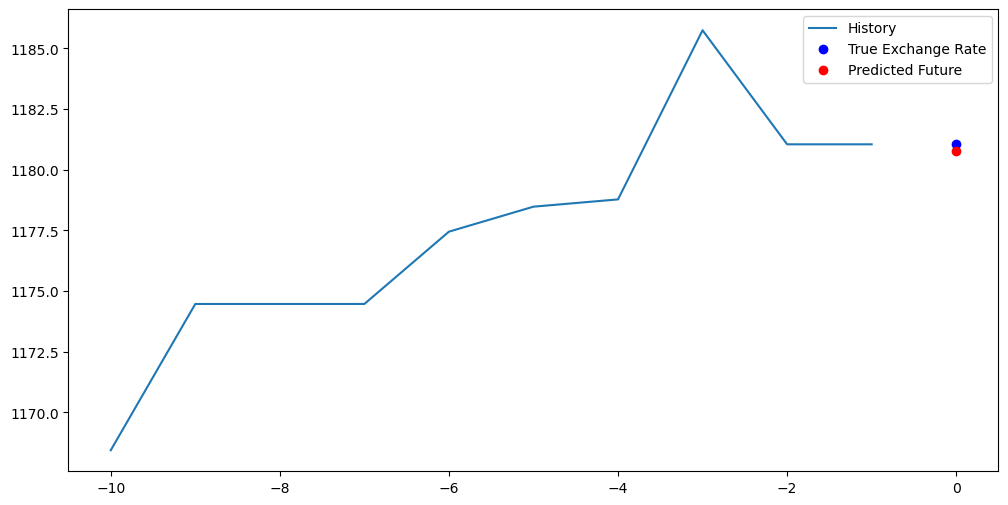

1/1 [==============================] - 0s 18ms/step


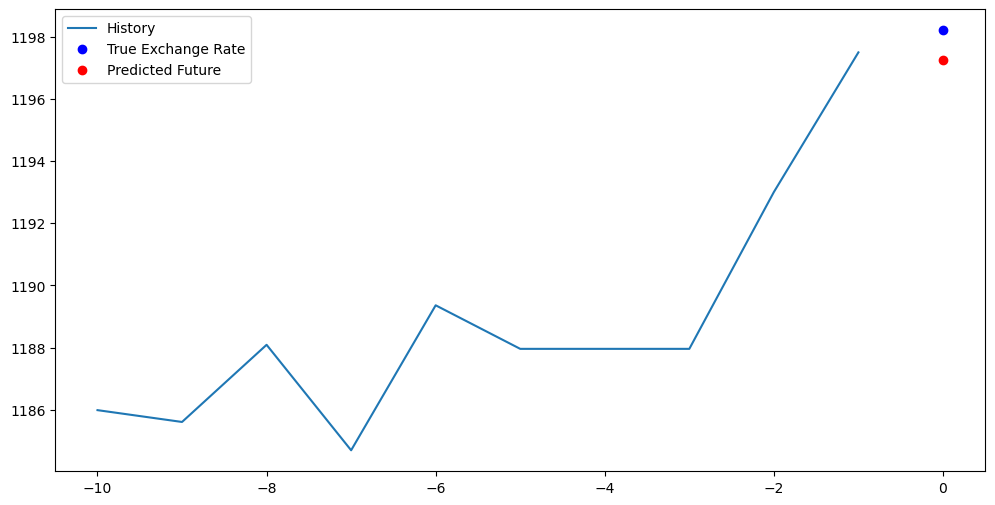

1/1 [==============================] - 0s 21ms/step


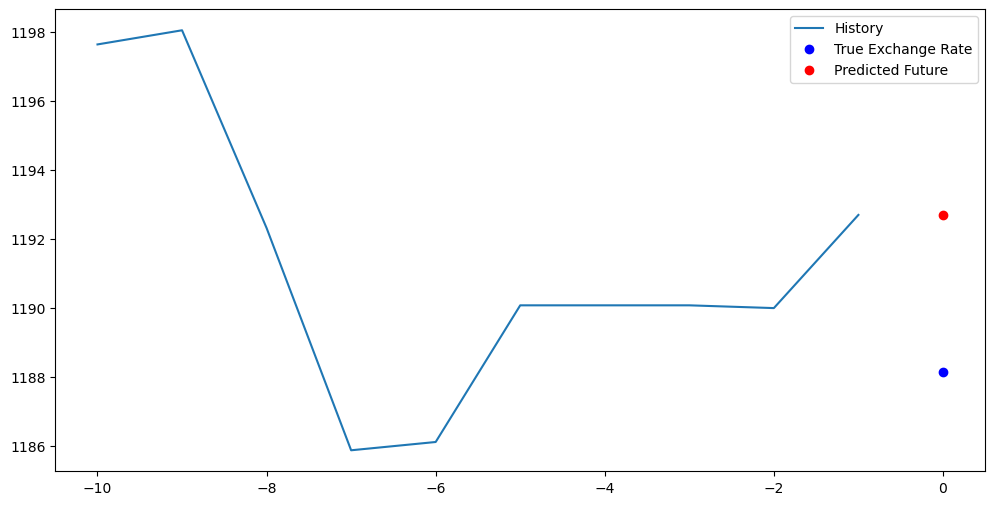

1/1 [==============================] - 0s 24ms/step


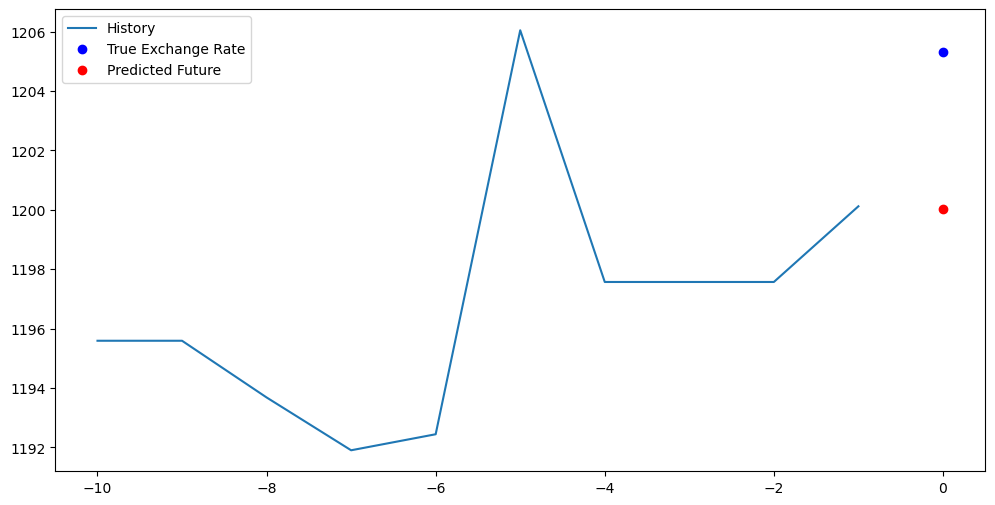

1/1 [==============================] - 0s 43ms/step


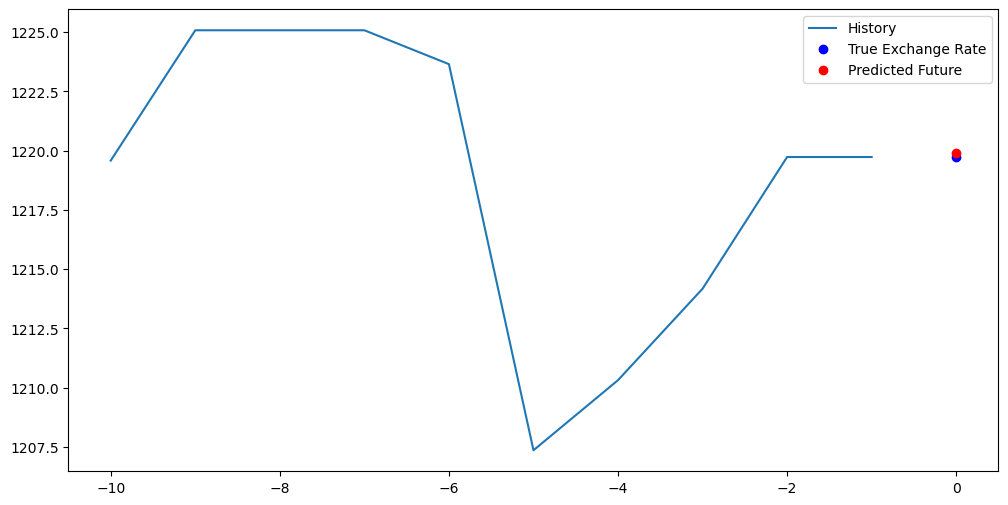

1/1 [==============================] - 0s 16ms/step


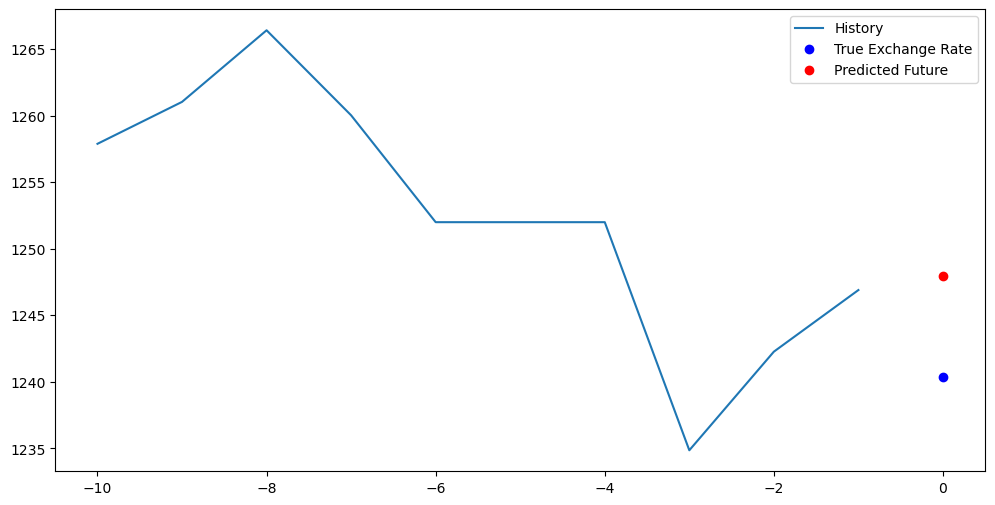

1/1 [==============================] - 0s 16ms/step


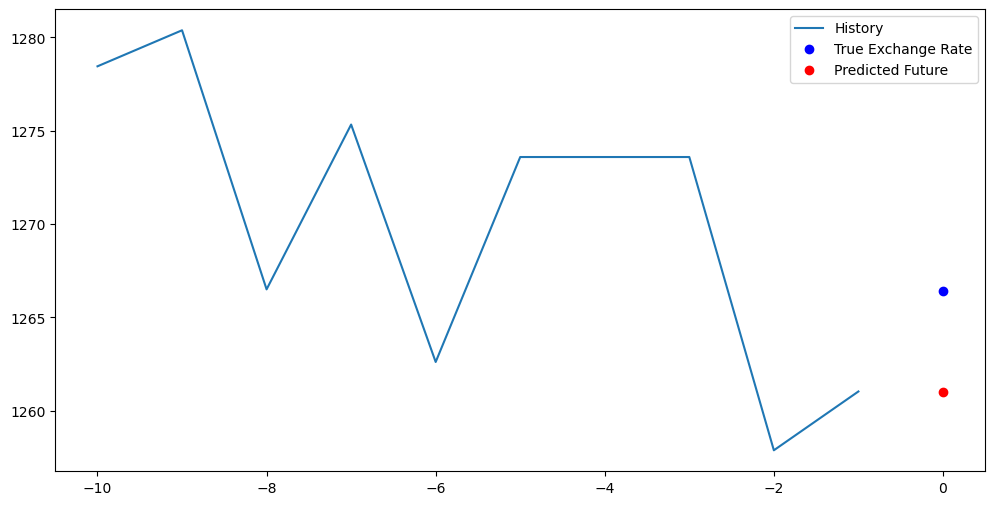

1/1 [==============================] - 0s 16ms/step


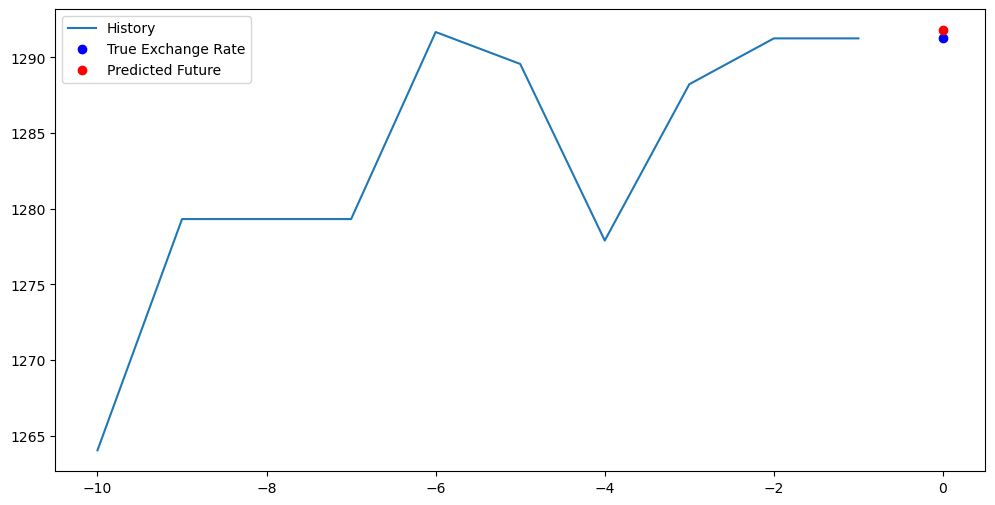

1/1 [==============================] - 0s 16ms/step


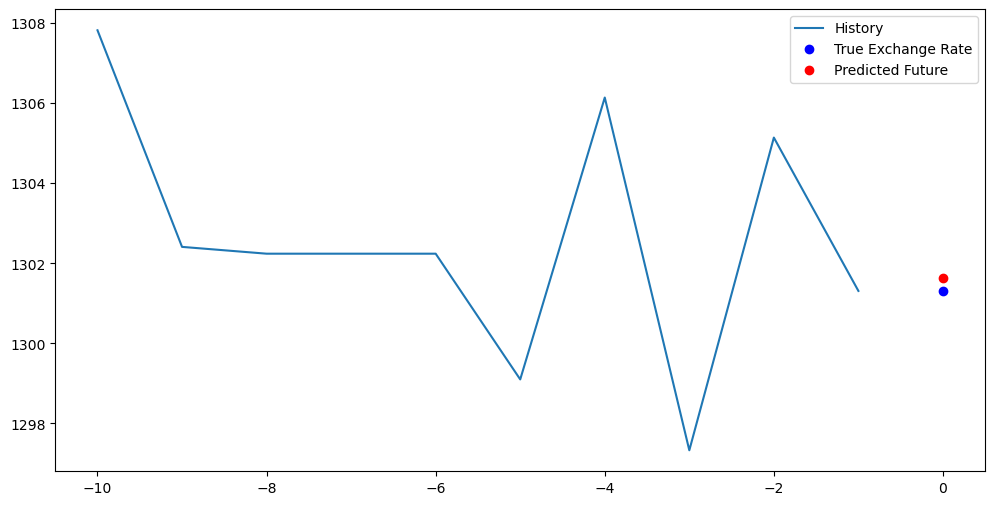

1/1 [==============================] - 0s 31ms/step


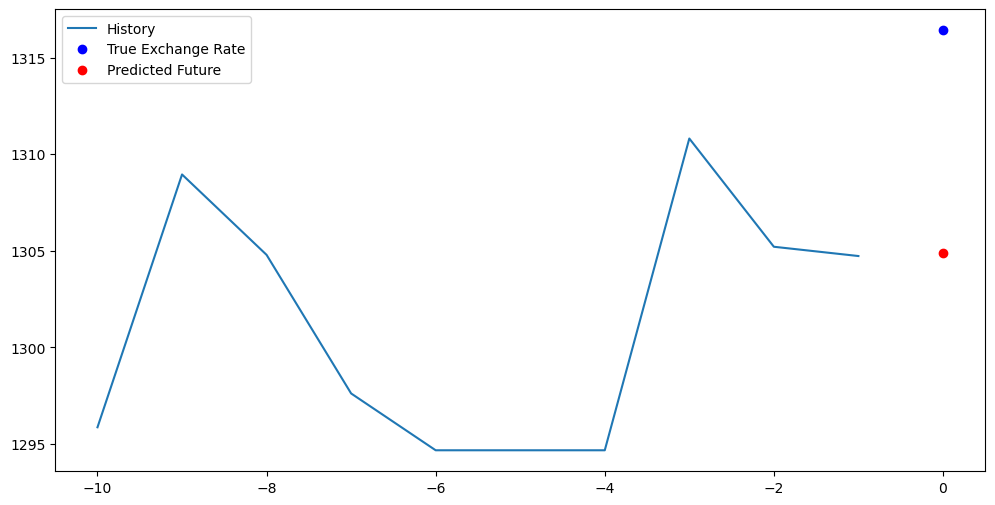

1/1 [==============================] - 0s 37ms/step


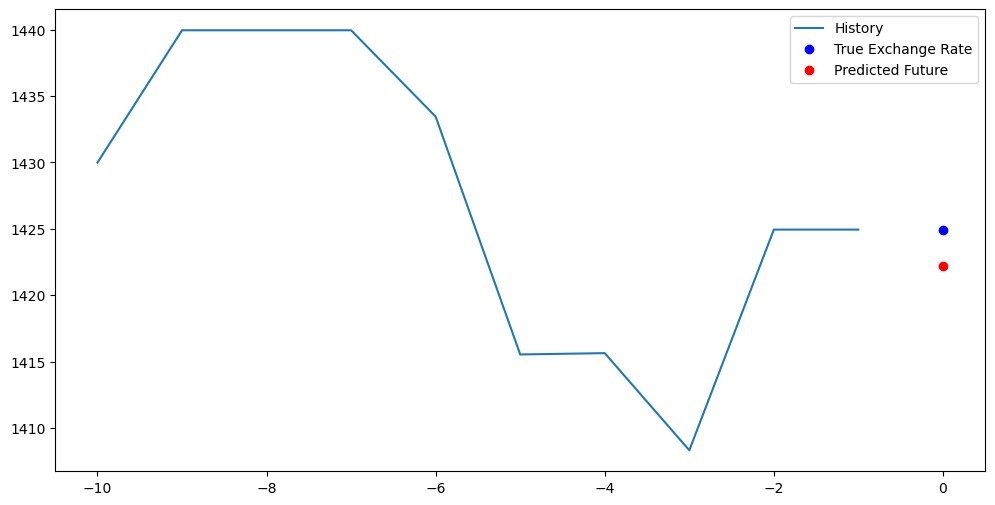

1/1 [==============================] - 0s 33ms/step


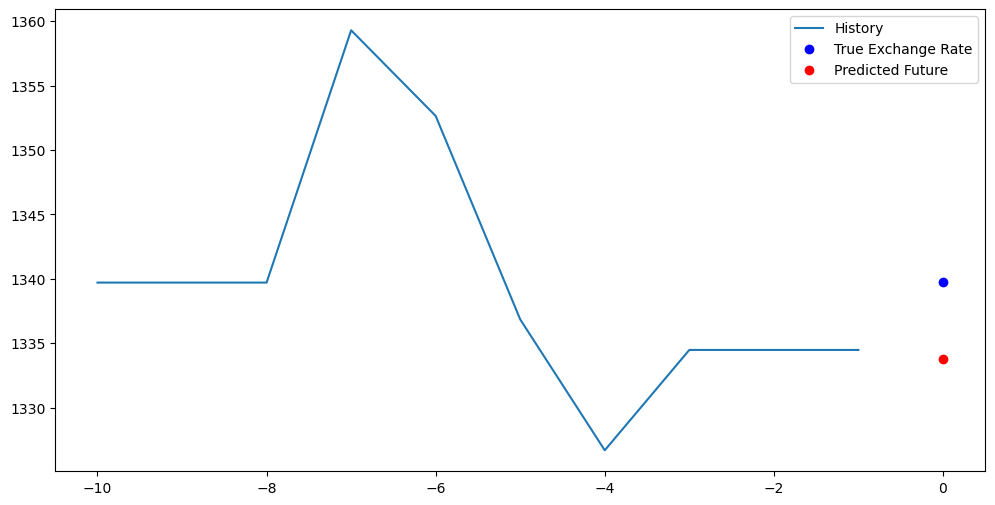

1/1 [==============================] - 0s 55ms/step


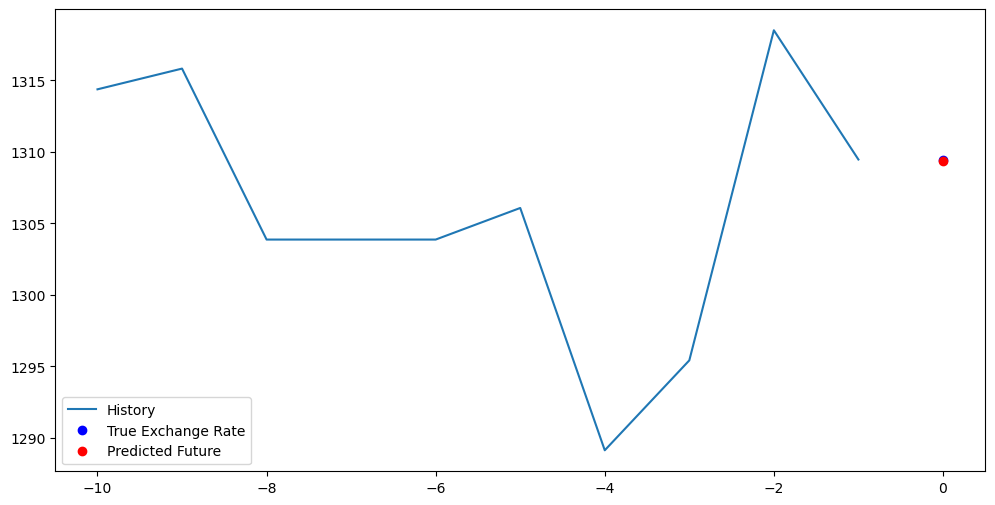

1/1 [==============================] - 0s 21ms/step


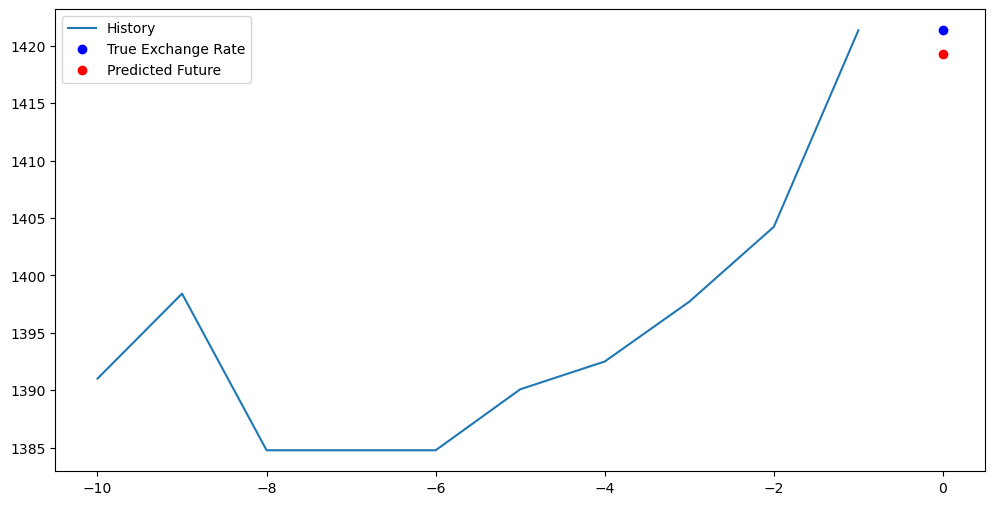

1/1 [==============================] - 0s 33ms/step


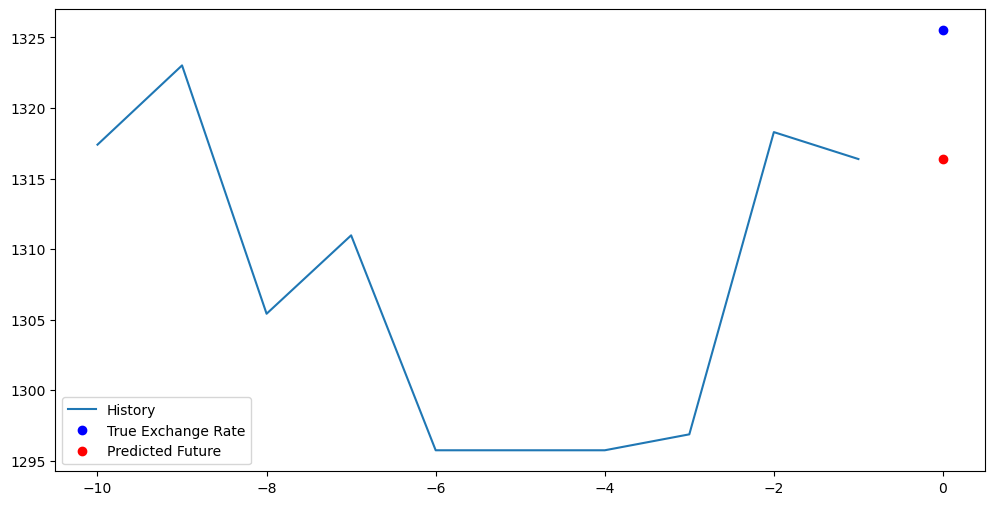

1/1 [==============================] - 0s 22ms/step


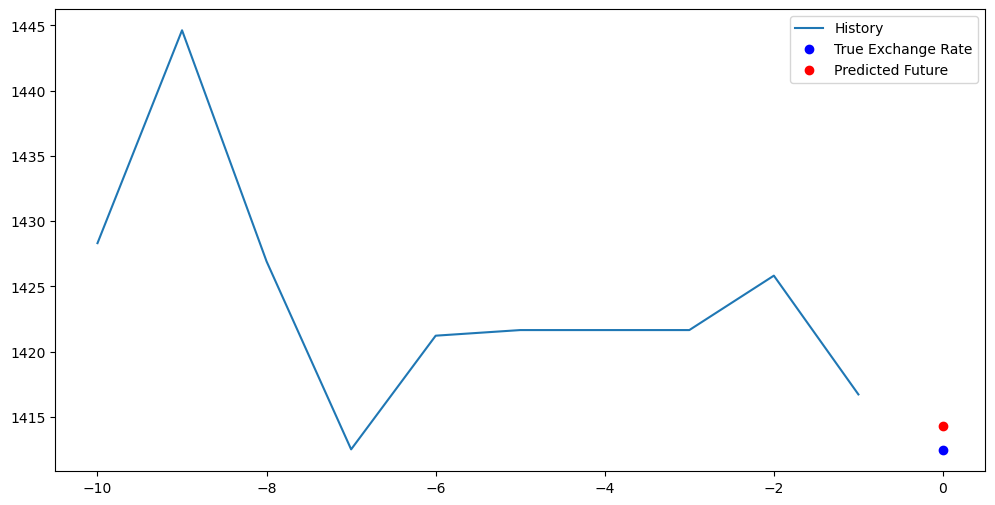

1/1 [==============================] - 0s 37ms/step


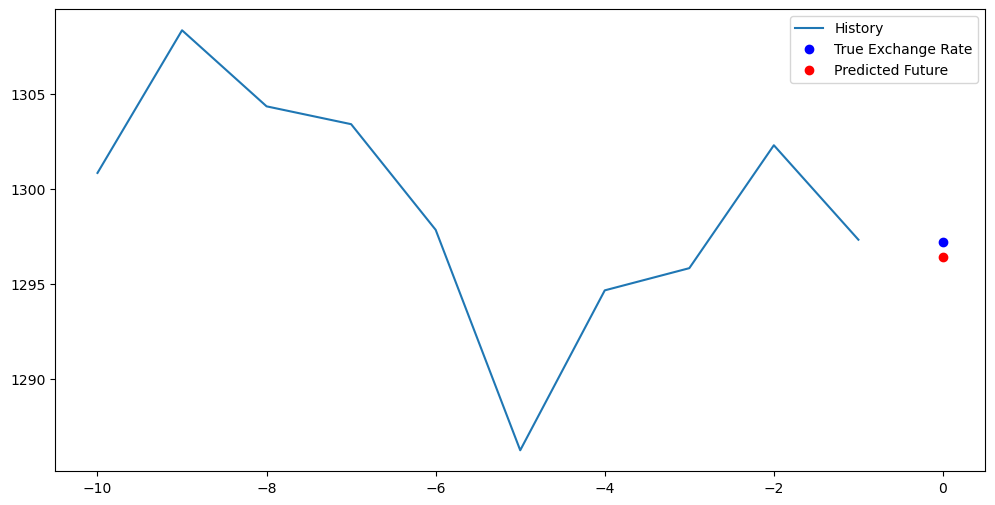

1/1 [==============================] - 0s 21ms/step


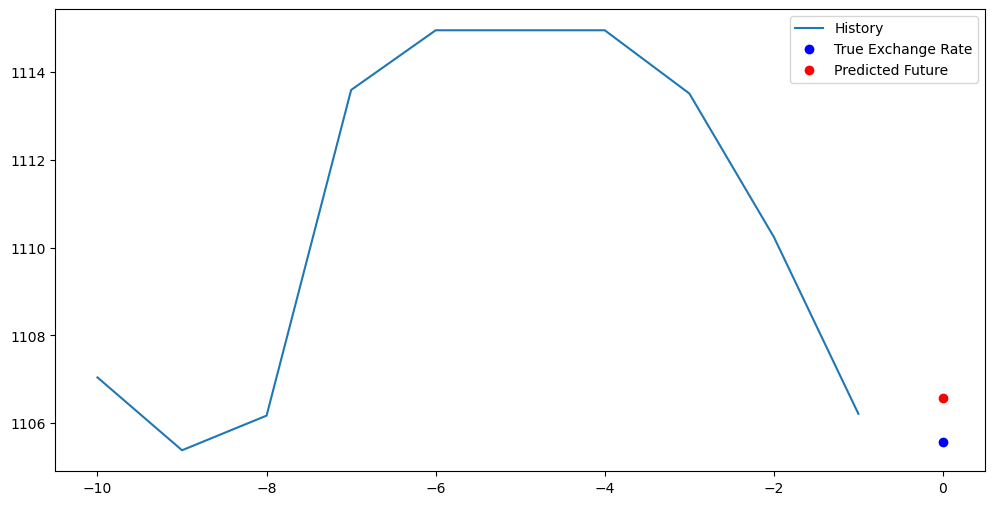

1/1 [==============================] - 0s 46ms/step


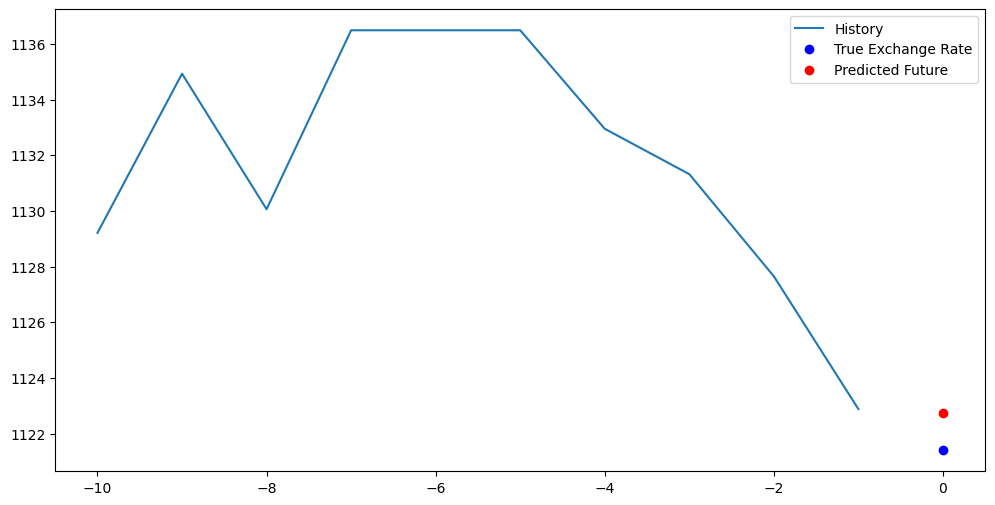

1/1 [==============================] - 0s 20ms/step


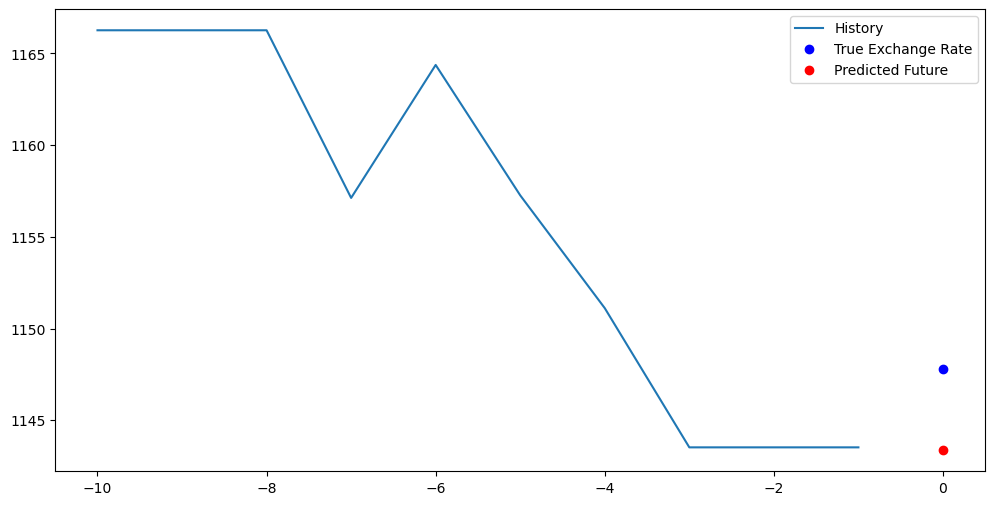

1/1 [==============================] - 0s 16ms/step


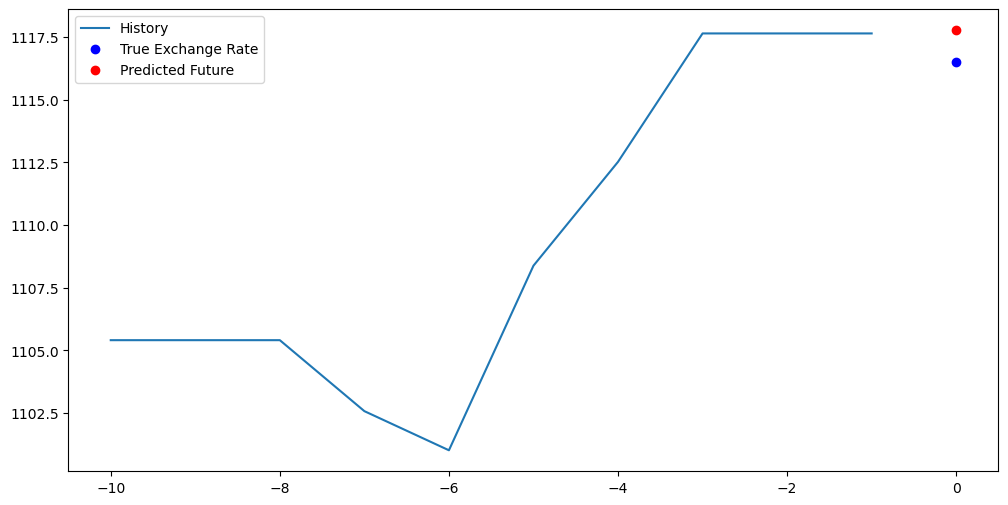

1/1 [==============================] - 0s 23ms/step


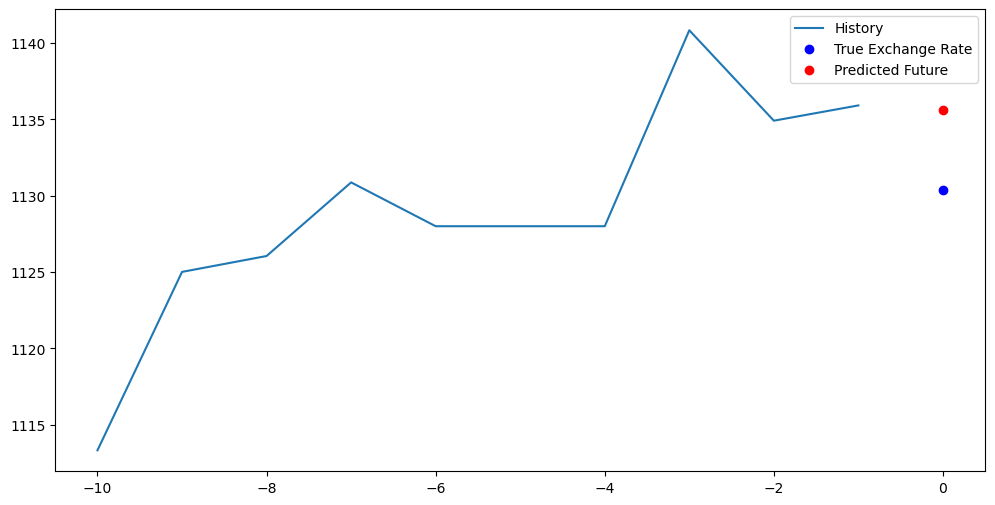

1/1 [==============================] - 0s 36ms/step


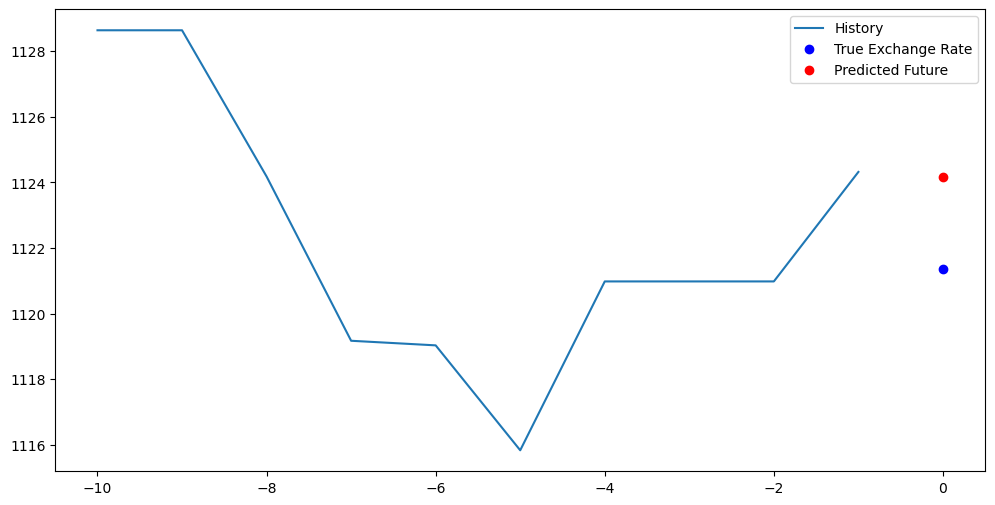

1/1 [==============================] - 0s 47ms/step


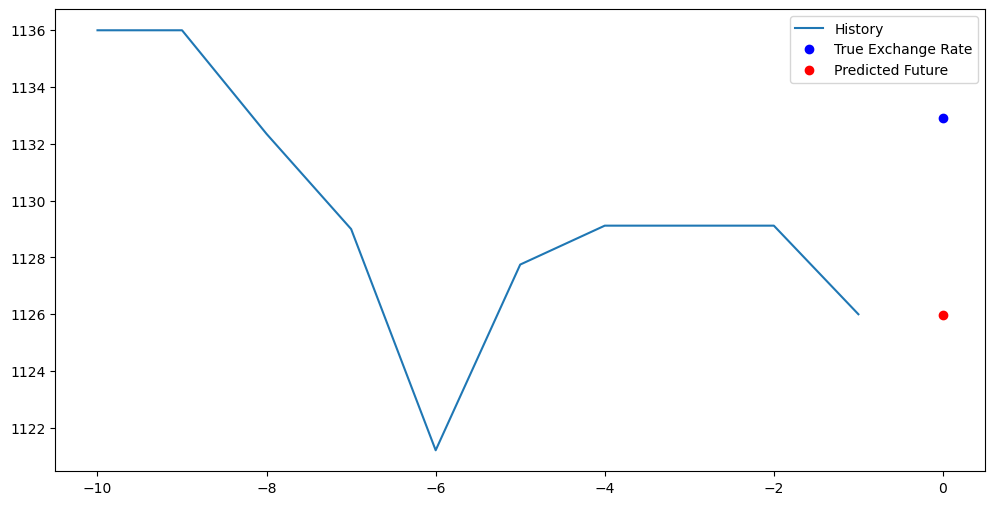

1/1 [==============================] - 0s 26ms/step


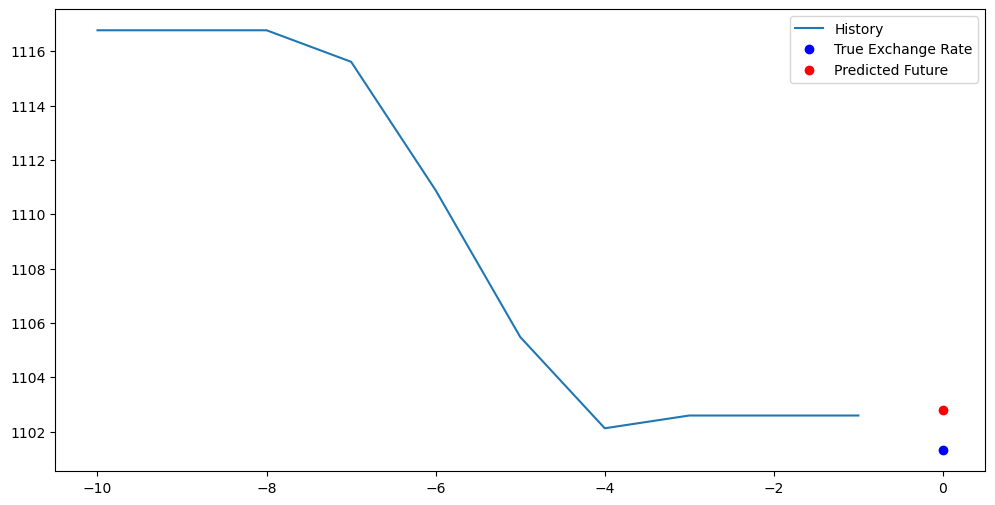

1/1 [==============================] - 0s 28ms/step


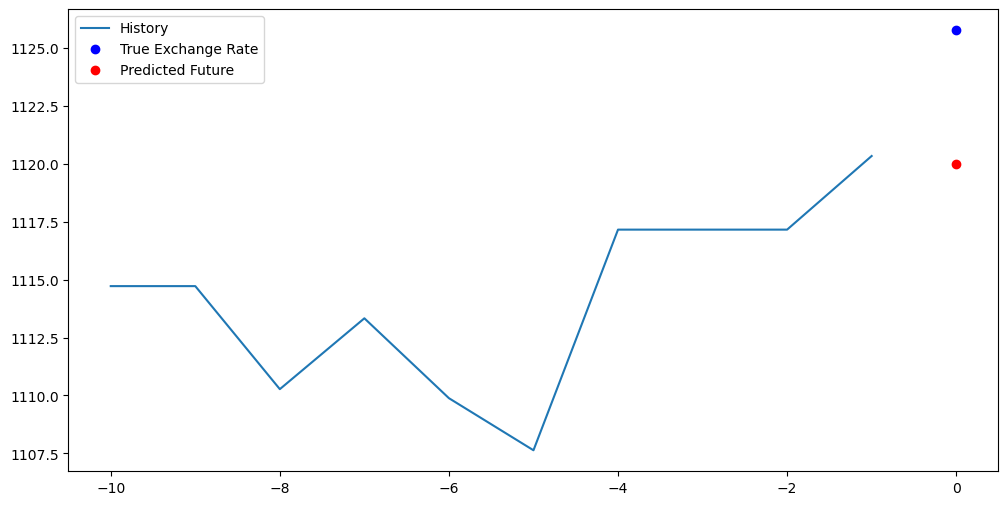

1/1 [==============================] - 0s 28ms/step


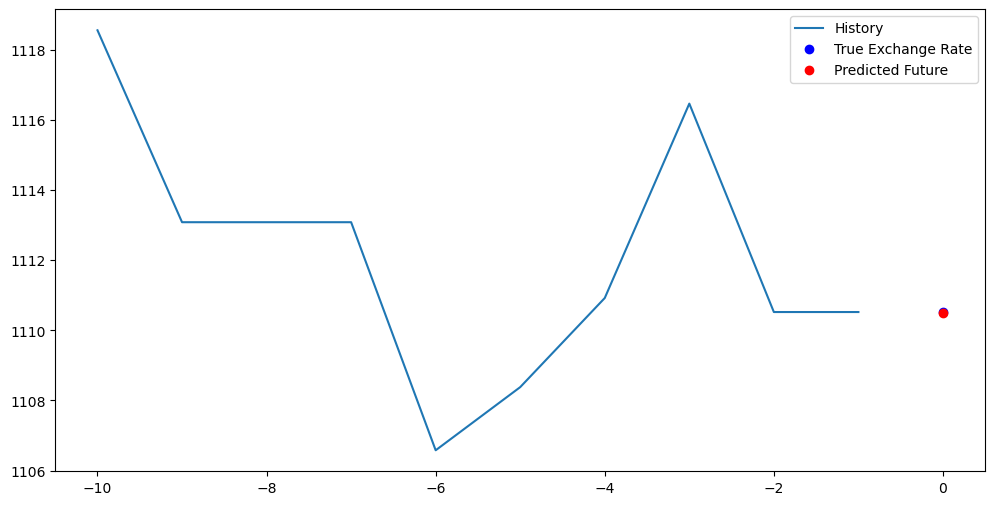

1/1 [==============================] - 0s 22ms/step


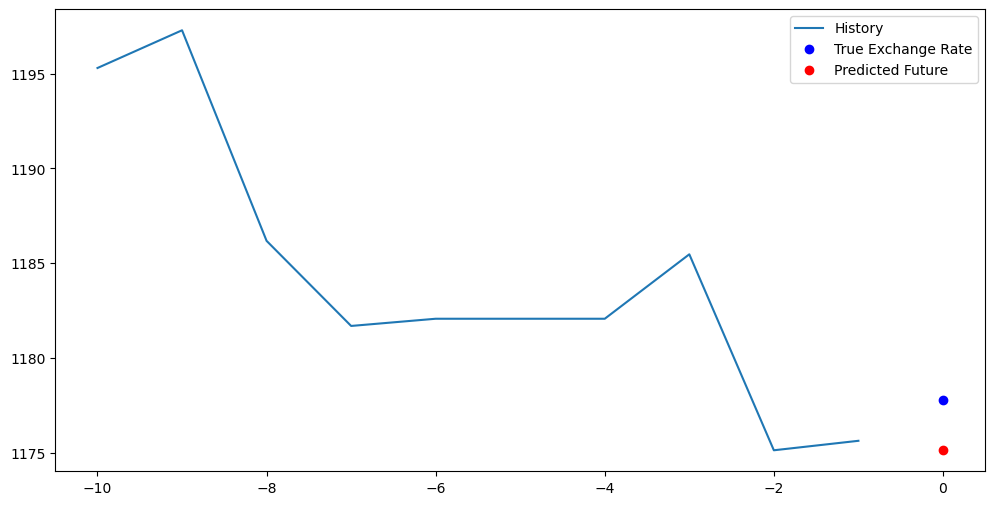

1/1 [==============================] - 0s 16ms/step


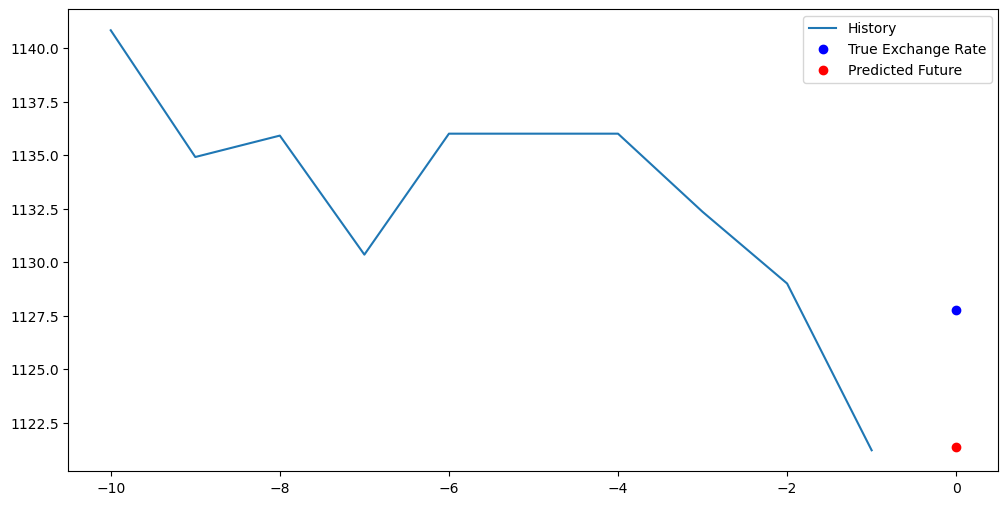

1/1 [==============================] - 0s 30ms/step


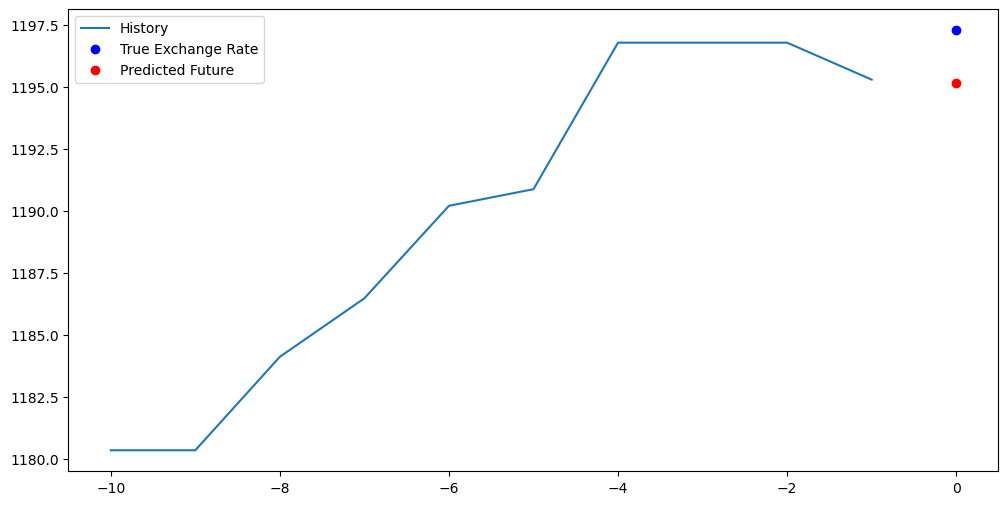

In [72]:
for x, y in val_data.take(100):
    multi_step_plot(x[0]*FX_St+FX_Mean , y[0]*FX_St+FX_Mean , model.predict(x)[0]*FX_St+FX_Mean )

# 다음날 예측

## 예측 데이터 표준화

In [73]:
pred = data[-past_history:].values
pred_mean = pred.mean(axis=0)
pred_std =pred.std(axis=0)
pred = (pred-pred_mean)/pred_std

In [112]:
pd.DataFrame(pred)

,0,1,2
0,1.147168,1.490867,-1.037394
1,0.033005,-1.242094,-0.661077
2,-2.291335,-0.547774,-0.998599
3,-0.605089,1.097912,-0.723150
4,-0.371054,1.097912,-0.723150
5,0.925135,0.953139,-0.723150
6,-0.071010,-0.967321,1.216630
7,-0.099014,-0.701411,1.216630
8,-0.099014,-0.095728,1.216630
9,1.431209,-1.085503,1.216630


In [74]:
predict= pd.DataFrame(predict, index = data.index[-len(predict):], columns=['predict'])

In [75]:
gather_all = pd.concat([data[-len(predict):], predict], axis=1)

In [109]:
gather_all[-10:]

,USD/KRW,predict
date,,
2023-03-21,1303.42,1303.725220
2023-03-22,1297.85,1302.824829
2023-03-23,1286.23,1296.896362
2023-03-24,1294.66,1286.057739
2023-03-26,1295.83,1294.681641
2023-03-27,1302.31,1295.638184
2023-03-28,1297.33,1301.620850
2023-03-29,1297.19,1296.414307
2023-03-30,1297.19,1296.579834


In [77]:
gather_all = gather_all.drop(['달러지수','crb'], axis=1)

In [78]:
(gather_all['USD/KRW'] - gather_all['predict'])[-10:]

date
2023-03-21    -0.305220
2023-03-22    -4.974829
2023-03-23   -10.666362
2023-03-24     8.602261
2023-03-26     1.148359
2023-03-27     6.671816
2023-03-28    -4.290850
2023-03-29     0.775693
2023-03-30     0.610166
2023-03-31     7.869175
dtype: float64

In [79]:
tmr = model.predict(pred.reshape(-1,pred.shape[-2],pred.shape[-1]))*FX_St+FX_Mean

1/1 [==============================] - 0s 19ms/step


In [80]:
pred.shape

(10, 3)

In [81]:
print(tmr)

[[1279.9738]]


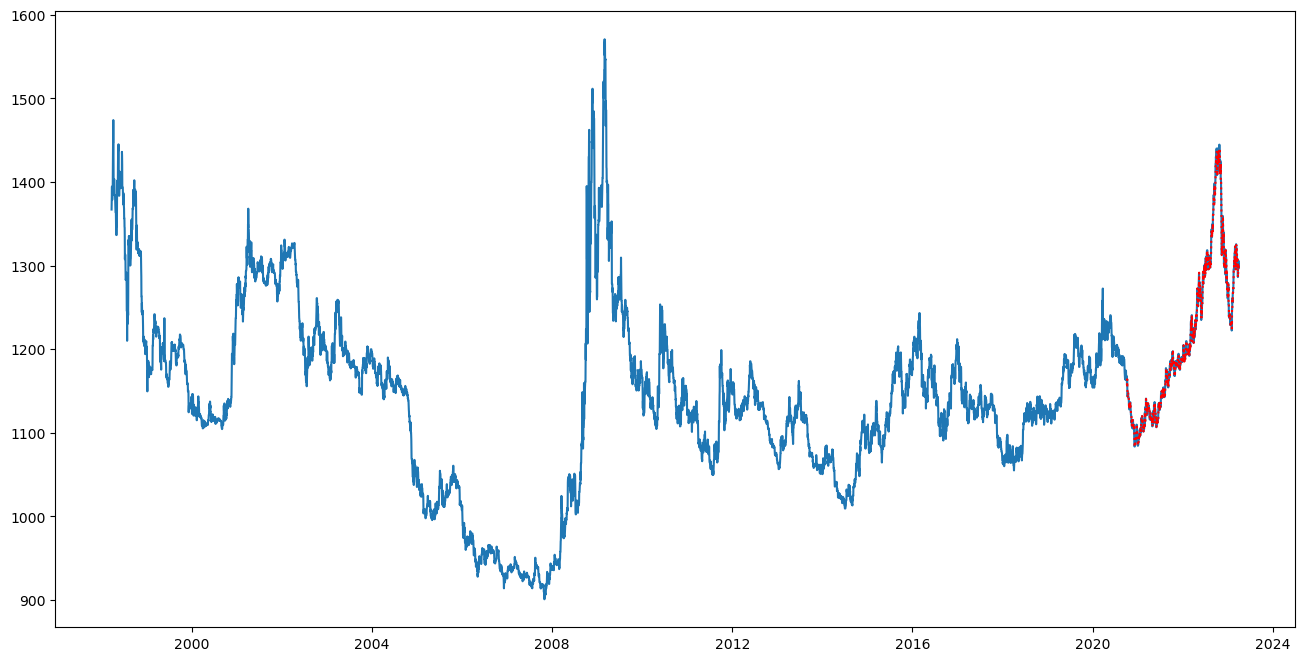

In [82]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
plt.plot(data['USD/KRW'])
#plt.plot(gather_all['USD/KRW'],'r--')
plt.plot(gather_all['predict'],'r:')
plt.show()

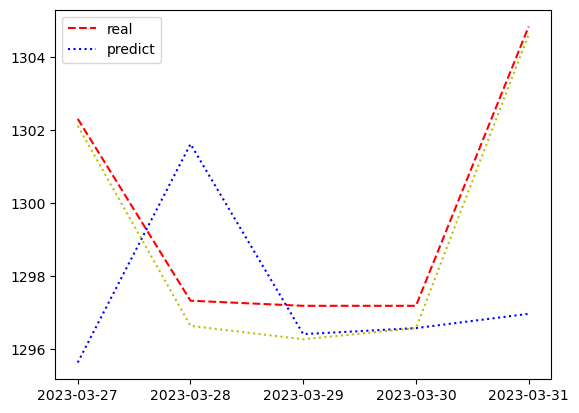

In [83]:
날짜 = 5
plt.plot(gather_all.index[-날짜:],  Y[-날짜:], 'r--', label ='real')
plt.plot(gather_all.index[-날짜:], predict[-날짜:], 'b:', label ='predict')
plt.plot(gather_all.index[-날짜:], (gather_all['predict'] + gather_all['USD/KRW'].diff())[-날짜:], 'y:')
plt.xticks(gather_all.index[-날짜:])
plt.legend()
plt.show()

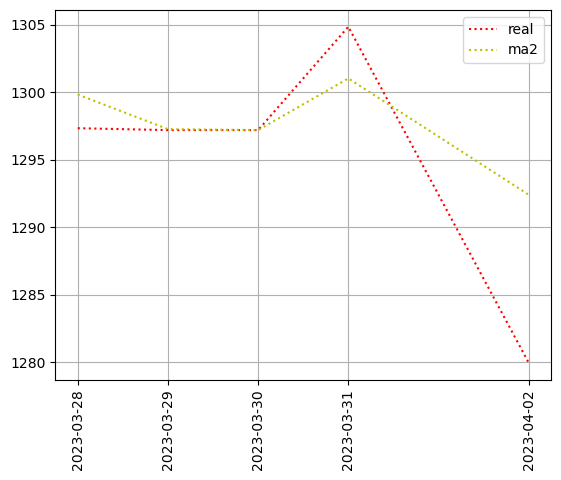

In [84]:
import matplotlib.pyplot as plt
MA = pd.DataFrame(index = gather_all.index)
날짜 = 5
# Moving average
MA['real'] = gather_all['USD/KRW']
MA['predict'] =  gather_all['predict']
import datetime
from datetime import timedelta
today = datetime.date.today()
# 내일 날짜: 오늘 + 1일
tomorrow = today + timedelta(days=1)
#print(tomorrow)

MA = pd.concat([MA, pd.DataFrame(tmr, index=[tomorrow], columns=['real'])])
#pd.concat([MA, pd.DataFrame(tmr, index=['new'], columns=['real'])])
MA['ma2'] = MA['real'].rolling(window=2).mean()
MA['ma3'] = MA['real'].rolling(window=3).mean()
MA['ma5' ]= MA['real'].rolling(window=5).mean()
#ma20 = new_gs['Adj Close'].rolling(window=60).mean()
#ma120 = new_gs['Adj Close'].rolling(window=120).mean()

# Insert columns

#np.set_printoptions(suppress= True, precision = 8)
# Plot
#plt.xticks(MA[-28:-25].index)
#plt.xlim(MA['real'][-28:-25].index )
plt.plot(MA[-날짜:].index, MA['real'][-날짜:],'r:', label='real')
plt.plot(MA[-날짜:].index, MA['ma2'][-날짜:],'y:', label='ma2')
#plt.plot(MA[-28:-25].index, MA['ma5'][-28:-25], label='ma3')
plt.xticks(MA[-날짜:].index)
#plt.plot(MA.index[-30:], MA['ma10'][-30:] , label='ma10')

plt.legend(loc="best")
plt.grid()
plt.xticks(rotation='vertical')
plt.show()

In [85]:
MA['real-ma2'] = MA['real'] - MA['ma2']

In [86]:
MA.iloc[-10:]

,real,predict,ma2,ma3,ma5,real-ma2
2023-03-22 00:00:00,1297.850000,1302.824829,1300.635000,1301.876667,1302.970000,-2.785000
2023-03-23 00:00:00,1286.230000,1296.896362,1292.040000,1295.833333,1300.046000,-5.810000
2023-03-24 00:00:00,1294.660000,1286.057739,1290.445000,1292.913333,1297.304000,4.215000
2023-03-26 00:00:00,1295.830000,1294.681641,1295.245000,1292.240000,1295.598000,0.585000
2023-03-27 00:00:00,1302.310000,1295.638184,1299.070000,1297.600000,1295.376000,3.240000
2023-03-28 00:00:00,1297.330000,1301.620850,1299.820000,1298.490000,1295.272000,-2.490000
2023-03-29 00:00:00,1297.190000,1296.414307,1297.260000,1298.943333,1297.464000,-0.070000
2023-03-30 00:00:00,1297.190000,1296.579834,1297.190000,1297.236667,1297.970000,0.000000
2023-03-31 00:00:00,1304.840000,1296.970825,1301.015000,1299.740000,1299.772000,3.825000
2023-04-02,1279.973755,NaN,1292.406877,1294.001252,1295.304751,-12.433123


In [87]:
if MA.iloc[-2]['real-ma2']>0: #실제값이 MA2값 보다 크다 
    if MA.iloc[-2]['real-ma2']*MA.iloc[-1]['real-ma2'] <0: #곱이 음수면 
        print('내일 환율이 떨어질 가능성이 크다') # 환율 
    else:
        print('내일 환율이 어떻게 될지 모른다')
        
elif MA.iloc[-2]['real-ma2']<0:
    if MA.iloc[-2]['real-ma2']*MA.iloc[-1]['real-ma2'] <0:
        print('내일 환율이 오를 가능성이 크다')
    else:
        print('내일 환율이 어떻게 될지 모른다')
        
else:
    if MA.iloc[-3]['real-ma2']>0:
        if MA.iloc[-3]['real-ma2']*MA.iloc[-2]['real-ma2'] <0:
            print('내일 환율이 떨어질 가능성이 크다')
        else:
            print('내일 환율이 어떻게 될지 모른다')
    elif MA.iloc[-3]['real-ma2']<0:
        if MA.iloc[-3]['real-ma2']*MA.iloc[-2]['real-ma2'] <0:
            print('내일 환율이 오를 가능성이 크다')
        else:
            print('내일 환율이 어떻게 될지 모른다')
    else:
        if MA.iloc[-4]['real-ma2']>0:
            if MA.iloc[-4]['real-ma2']*MA.iloc[-3]['real-ma2'] <0:
                print('내일 환율이 떨어질 가능성이 크다')
            else:
                print('내일 환율이 어떻게 될지 모른다')
        elif MA.iloc[-4]['real-ma2']<0:
            if MA.iloc[-4]['real-ma2']*MA.iloc[-3]['real-ma2'] <0:
                print('내일 환율이 오를 가능성이 크다')
            else:
                print('내일 환율이 어떻게 될지 모른다')
        else:
            print('내일 환율이 어떻게 될지 모른다')
        

내일 환율이 떨어질 가능성이 크다
